In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from tp7.tp7 import Tape7
from srfs.srfs import SRFS
import scipy.integrate as integrate
from collections import defaultdict

In [2]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

srf = SRFS("./data/libera_srfs_20241017.csv")
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']

In [3]:
# def plot_radiance(rads, int_rads, title, runnum, s_or_l=1):
#     #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]
#
#     figure = plt.figure(2, figsize=(8,6))
#     ax = plt.axes()
#     ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :], 'r-', label='Radiance')
#
#     ax.legend(prop={"size":20})
#     plt.title("%s Radiance Spectrum"%title, fontsize=40)
#     plt.xticks(fontsize=20)
#     plt.yticks(fontsize=20)
#     plt.xlabel('Wavelength um', fontsize=30)
#     plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
#     if s_or_l == 2:
#         plt.xlim(0,50)
#     else:
#         plt.xlim(0,5)
def plot_radiance(rads, int_rads, title, runnum, s_or_l=1):
    # access wavelength with rads[runnum, 0, :], swrad with rads[runnum, 1, :], lwrad with rads[runnum, 2, :]

    figure = plt.figure(2, figsize=(8, 6))
    ax = plt.axes()

    # Plot the radiance spectrum
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :], 'r-', label='Radiance')

    # Plot the integrated radiance or additional radiance curve (modify label as needed)
    ax.plot(rads[runnum, 0, :], int_rads[runnum, :], 'b--', label='Integrated Radiance')

    # Add legend and labels
    ax.legend(prop={"size": 20})
    plt.title("%s Radiance Spectrum" % title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength (μm)', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} μm^{-1} sr^{-1}$', fontsize=30)

    # Set wavelength range based on shortwave or longwave
    if s_or_l == 2:
        plt.xlim(0, 50)
    else:
        plt.xlim(0, 5)


In [4]:
def plot_integrated_radiance(rads, title, idx, wvs, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(wvs, rads[idx, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)

In [5]:
a00_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a00_files]
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

a41_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a41_files]
titles = [file.title for file in a41_data]
a41 = {title: file for title, file in zip(titles, a41_data)}

a60_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a60_files]
titles = [file.title for file in a60_data]
a60 = {title: file for title, file in zip(titles, a60_data)}

a75_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a75_files]
titles = [file.title for file in a75_data]
a75 = {title: file for title, file in zip(titles, a75_data)}

a85_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a85_files]
titles = [file.title for file in a85_data]
a85 = {title: file for title, file in zip(titles, a85_data)}

In [6]:
a85

{'Land': <tp7.tp7.Tape7 at 0x354c4db50>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x3048a1790>,
 'Snow': <tp7.tp7.Tape7 at 0x30484caa0>,
 'Deep Convective Cloud': <tp7.tp7.Tape7 at 0x331a24f20>,
 'Cloudy Ocean': <tp7.tp7.Tape7 at 0x304eda150>}

In [7]:
land_a00 = a00["Land"]
land_a00.rads.shape # runs, wv, data

(630, 3, 4000)

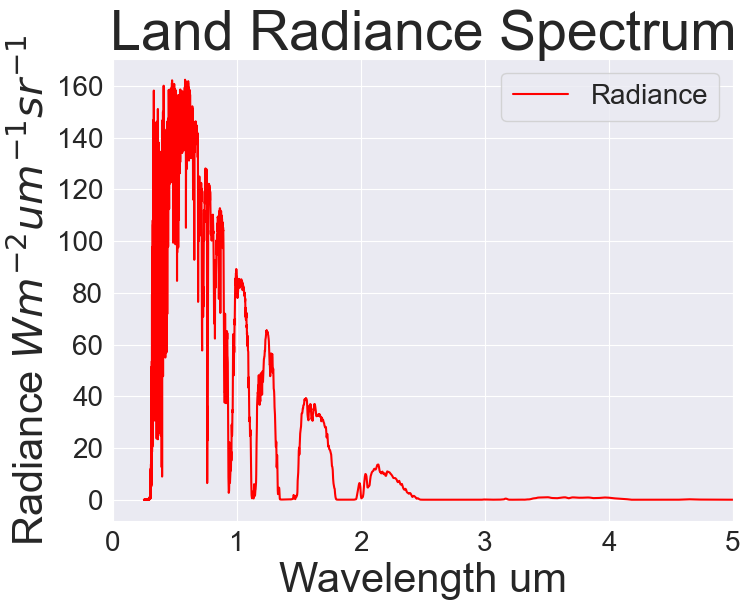

In [15]:
plot_radiance(dc.rads, land_a00.title, 0, s_or_l=1)

In [8]:
land_a00.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Land,0.0,0.000,0.0,0,0,101.967819,98.435473,75.727145,0.016809
1,Land,0.0,0.000,0.0,1,1,103.227094,69.392565,75.293403,0.003139
2,Land,0.0,0.000,0.0,1,2,155.619541,60.644086,113.325768,0.002398
3,Land,0.0,0.000,0.0,1,3,250.712675,93.578042,183.088022,0.021329
4,Land,0.0,0.000,0.0,1,4,339.815605,86.650577,247.891967,0.029803
...,...,...,...,...,...,...,...,...,...,...
625,Land,0.0,79.914,172.5,0,625,72.466530,58.907500,52.043946,0.001230
626,Land,0.0,79.914,172.5,1,626,83.026982,46.597913,59.707949,0.002290
627,Land,0.0,79.914,172.5,1,627,106.881209,44.111608,77.204551,0.002583
628,Land,0.0,79.914,172.5,1,628,157.489675,58.372397,114.987698,0.008196


In [9]:
a00["Snow"].describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Snow,0.000,0.000,0.0,0,0,1.602011e-06,0.000491,1.233818e-06,5.401733e-10
1,Snow,0.000,0.000,0.0,1,1,1.618549e-06,0.000483,1.243242e-06,3.165444e-09
2,Snow,0.000,0.000,0.0,1,2,1.534858e-06,0.000492,1.177596e-06,5.126559e-10
3,Snow,0.000,0.000,0.0,1,3,2.903169e-06,0.000469,2.209365e-06,6.147627e-08
4,Snow,0.000,0.000,0.0,1,4,2.261459e-06,0.000490,1.728870e-06,2.828023e-08
...,...,...,...,...,...,...,...,...,...,...
310,Snow,9.156,89.947,172.5,0,310,6.375241e-07,0.000448,4.811997e-07,1.389037e-10
311,Snow,9.156,89.947,172.5,1,311,7.528710e-07,0.000417,5.559778e-07,1.634299e-08
312,Snow,9.156,89.947,172.5,1,312,5.552769e-07,0.000446,4.189763e-07,2.539906e-10
313,Snow,9.156,89.947,172.5,1,313,2.247316e-06,0.000437,1.738242e-06,3.679796e-08


In [23]:
sza00 = [dct.describer_df for dct in a00.values()]
sza00 = pd.concat(sza00, axis=0)
sza00

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Land,85.000,0.000,0.0,0,0,8.312447e+00,98.435431,6.062306e+00,3.342205e-04
1,Land,85.000,0.000,0.0,1,1,8.976469e+00,69.392603,6.505601e+00,2.766002e-04
2,Land,85.000,0.000,0.0,1,2,1.148042e+01,60.644071,8.353203e+00,3.181347e-04
3,Land,85.000,0.000,0.0,1,3,1.436688e+01,93.578245,1.045812e+01,4.108197e-04
4,Land,85.000,0.000,0.0,1,4,1.994112e+01,86.650246,1.464458e+01,2.159560e-03
...,...,...,...,...,...,...,...,...,...,...
79,Cloudy Ocean,84.092,89.947,142.5,1,79,5.495387e-07,0.000475,4.264091e-07,3.312347e-09
80,Cloudy Ocean,83.845,89.947,172.5,1,80,5.875353e-07,0.000460,4.589614e-07,1.550701e-09
81,Cloudy Ocean,83.845,89.947,172.5,1,81,6.149711e-07,0.000455,4.802549e-07,1.849066e-09
82,Cloudy Ocean,83.845,89.947,172.5,1,82,4.518198e-07,0.000476,3.508038e-07,1.036812e-10


In [61]:
sza85 = [dct.describer_df for dct in a85.values()]
sza85 = pd.concat(sza85, axis=0)
sza85

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Land,85.000,0.000,0.0,0,0,8.312447e+00,98.435431,6.062306e+00,3.342205e-04
1,Land,85.000,0.000,0.0,1,1,8.976469e+00,69.392603,6.505601e+00,2.766002e-04
2,Land,85.000,0.000,0.0,1,2,1.148042e+01,60.644071,8.353203e+00,3.181347e-04
3,Land,85.000,0.000,0.0,1,3,1.436688e+01,93.578245,1.045812e+01,4.108197e-04
4,Land,85.000,0.000,0.0,1,4,1.994112e+01,86.650246,1.464458e+01,2.159560e-03
...,...,...,...,...,...,...,...,...,...,...
79,Cloudy Ocean,84.092,89.947,142.5,1,79,5.495387e-07,0.000475,4.264091e-07,3.312347e-09
80,Cloudy Ocean,83.845,89.947,172.5,1,80,5.875353e-07,0.000460,4.589614e-07,1.550701e-09
81,Cloudy Ocean,83.845,89.947,172.5,1,81,6.149711e-07,0.000455,4.802549e-07,1.849066e-09
82,Cloudy Ocean,83.845,89.947,172.5,1,82,4.518198e-07,0.000476,3.508038e-07,1.036812e-10


In [53]:
sza00.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)'],
      dtype='object')

In [38]:
dc = a00["Deep Convective Cloud"]
dc.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Deep Convective Cloud,85.000,0.00000,0.0,1,0,20.163600,27.945048,14.825230,0.000670
1,Deep Convective Cloud,85.000,0.00000,0.0,1,1,20.550756,28.648690,15.114731,0.000633
2,Deep Convective Cloud,85.000,0.00000,0.0,1,2,20.607431,31.656736,15.142934,0.000530
3,Deep Convective Cloud,85.506,29.49001,7.5,1,3,20.025927,28.077062,14.750117,0.001263
4,Deep Convective Cloud,85.506,29.49001,7.5,1,4,20.320229,28.757337,14.965945,0.001216
...,...,...,...,...,...,...,...,...,...,...
58,Deep Convective Cloud,76.998,79.91400,142.5,1,58,62.199197,31.861680,44.879454,0.001803
59,Deep Convective Cloud,76.998,79.91400,142.5,1,59,63.972217,34.170336,46.139023,0.002402
60,Deep Convective Cloud,75.000,79.91400,172.5,1,60,70.008544,31.318456,50.496875,0.001818
61,Deep Convective Cloud,75.000,79.91400,172.5,1,61,71.543522,31.861702,51.509119,0.001746


In [39]:
dc_00 = dc.describer_df
dc_00

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Deep Convective Cloud,85.000,0.00000,0.0,1,0,20.163600,27.945048,14.825230,0.000670
1,Deep Convective Cloud,85.000,0.00000,0.0,1,1,20.550756,28.648690,15.114731,0.000633
2,Deep Convective Cloud,85.000,0.00000,0.0,1,2,20.607431,31.656736,15.142934,0.000530
3,Deep Convective Cloud,85.506,29.49001,7.5,1,3,20.025927,28.077062,14.750117,0.001263
4,Deep Convective Cloud,85.506,29.49001,7.5,1,4,20.320229,28.757337,14.965945,0.001216
...,...,...,...,...,...,...,...,...,...,...
58,Deep Convective Cloud,76.998,79.91400,142.5,1,58,62.199197,31.861680,44.879454,0.001803
59,Deep Convective Cloud,76.998,79.91400,142.5,1,59,63.972217,34.170336,46.139023,0.002402
60,Deep Convective Cloud,75.000,79.91400,172.5,1,60,70.008544,31.318456,50.496875,0.001818
61,Deep Convective Cloud,75.000,79.91400,172.5,1,61,71.543522,31.861702,51.509119,0.001746


In [ ]:
sza

In [43]:
vza = sza00['VZA'].values
raz = sza00['RAZ'].values
integrated_sw_val_array = sza00["Shortwave Unfiltered Rads (Integrated)"].values
integrated_sw_filtered_array = dc_00["Shortwave Filtered Rads (Integrated)"].values
# scene_types = sza00['Scene'].unique()

# Group by unique VZA, RAZ combinations
unique_geometries = sza00.groupby(["VZA", "RAZ"])

# Arrays for tracking
scene_integrated_sw, scene_sw_filtered_array = [], []
scene_coefficient_sw, scene_sw_filter_fit, scene_sw_ratio_for_plot = [], [], []

# Loop through each unique geometry
for (vza_val, raz_val), group in unique_geometries:
    group_integrated_sw = group["Shortwave Unfiltered Rads (Integrated)"].values
    group_filtered_sw = group["Shortwave Filtered Rads (Integrated)"].values
    scene_type = group["Scene"].values[0]  # Get the scene type for this group

    scene_integrated_sw.append(group_integrated_sw)
    scene_sw_filtered_array.append(group_filtered_sw)

    # Fit quadratic and calculate filtered fit
    coeff = np.polynomial.polynomial.polyfit(group_filtered_sw, group_integrated_sw, 2)
    scene_coefficient_sw.append(coeff)
    scene_sw_filter_fit.append(np.polynomial.polynomial.polyval(group_filtered_sw, coeff))

    # Calculate error regression curve
    error_curve = ((scene_sw_filter_fit[-1] - group_integrated_sw) / group_integrated_sw) * 100
    scene_sw_ratio_for_plot.append(error_curve)

# Plot filtered vs unfiltered radiances for each geometry
geometry_keys = list(unique_geometries.groups.keys())
# for i in range(len(scene_integrated_sw)):
#     plt.figure()
#     plt.plot(scene_integrated_sw[i], scene_sw_filter_fit[i], label="Quadratic Fit")
#     plt.scatter(scene_sw_filter_fit[i], scene_integrated_sw[i], label="Fit vs Unfiltered")
#     plt.scatter(scene_integrated_sw[i], scene_sw_filtered_array[i], label="Unfiltered vs Filtered")
#
#     # Get the VZA and RAZ values for the current plot
#     vza_val, raz_val = geometry_keys[i]
#     scene_type = sza00.loc[
#         (sza00['VZA'] == vza_val) & (sza00['RAZ'] == raz_val), 'Scene'
#     ].values[0]  # Dynamically fetch the scene type
#
#     # Set the title dynamically based on the scene
#     plt.title(f"{scene_type}, SZA=00, VZA={vza_val}, RAZ={raz_val}")
#     plt.xlabel("Unfiltered SW Radiance [W/m²/sr]")
#     plt.ylabel("Filtered SW Radiance [W/m²/sr]")
#     plt.legend(["Second order polynomial fit", "Fit vs Unfiltered", "Integrated vs Filtered"])
#     plt.show()

In [47]:
vza = sza00['VZA'].values
raz = sza00['RAZ'].values
integrated_sw_val_array = sza00["Shortwave Unfiltered Rads (Integrated)"].values
integrated_sw_filtered_array = sza00["Shortwave Filtered Rads (Integrated)"].values
scene_types = sza00['Scene'].unique()

# Group by unique VZA, RAZ combinations
unique_geometries = sza00.groupby(["VZA", "RAZ"])
print(unique_geometries)

# Arrays for tracking
scene_integrated_sw, scene_sw_filtered_array = [], []
scene_coefficient_sw, scene_sw_filter_fit, scene_sw_ratio_for_plot = [], [], []

# Loop through each unique geometry
for (vza_val, raz_val), group in unique_geometries:
    group_integrated_sw = group["Shortwave Unfiltered Rads (Integrated)"].values
    group_filtered_sw = group["Shortwave Filtered Rads (Integrated)"].values

    scene_integrated_sw.append(group_integrated_sw)
    scene_sw_filtered_array.append(group_filtered_sw)

    # Fit quadratic and calculate filtered fit
    coeff = np.polynomial.polynomial.polyfit(group_filtered_sw, group_integrated_sw, 2)
    scene_coefficient_sw.append(coeff)
    scene_sw_filter_fit.append(np.polynomial.polynomial.polyval(group_filtered_sw, coeff))

    # Calculate error regression curve
    error_curve = ((scene_sw_filter_fit[-1] - group_integrated_sw) / group_integrated_sw) * 100
    scene_sw_ratio_for_plot.append(error_curve)

# Plot filtered vs unfiltered radiances for each geometry
for i in range(len(scene_integrated_sw)):
    # plt.figure()
    # plt.plot(scene_integrated_sw[i], scene_sw_filter_fit[i], label="Quadratic Fit")
    # plt.scatter(scene_sw_filter_fit[i], scene_integrated_sw[i], label="Fit vs Unfiltered")
    # plt.scatter(scene_integrated_sw[i], scene_sw_filtered_array[i], label="Unfiltered vs Filtered")

    # Get the VZA and RAZ values for the current plot
    geometry_keys = list(unique_geometries.groups.keys())
    print(geometry_keys)
    vza_val, raz_val = geometry_keys[i]
    # plt.title(f"VZA={vza_val}, RAZ={raz_val}")
    # plt.xlabel("Unfiltered SW Radiance [W/m²/sr]")
    # plt.ylabel("Filtered SW Radiance [W/m²/sr]")
    # plt.legend()
    # plt.show()


[(0.0, 0.0), (29.490010000000012, 7.5), (29.490010000000012, 37.5), (29.490010000000012, 90.0), (29.490010000000012, 142.5), (29.490010000000012, 172.5), (30.0, 7.5), (30.0, 37.5), (30.0, 90.0), (30.0, 142.5), (30.0, 172.5), (44.12100000000001, 7.5), (44.12100000000001, 37.5), (44.12100000000001, 90.0), (44.12100000000001, 142.5), (44.12100000000001, 172.5), (45.0, 7.5), (45.0, 37.5), (45.0, 90.0), (45.0, 142.5), (45.0, 172.5), (58.5, 7.5), (58.5, 37.5), (58.5, 90.0), (58.5, 142.5), (58.5, 172.5), (60.0, 7.5), (60.0, 37.5), (60.0, 90.0), (60.0, 142.5), (60.0, 172.5), (79.914, 7.5), (79.914, 37.5), (79.914, 90.0), (79.914, 142.5), (79.914, 172.5), (89.947, 7.5), (89.947, 37.5), (89.947, 90.0), (89.947, 142.5), (89.947, 172.5)]
[(0.0, 0.0), (29.490010000000012, 7.5), (29.490010000000012, 37.5), (29.490010000000012, 90.0), (29.490010000000012, 142.5), (29.490010000000012, 172.5), (30.0, 7.5), (30.0, 37.5), (30.0, 90.0), (30.0, 142.5), (30.0, 172.5), (44.12100000000001, 7.5), (44.121000000

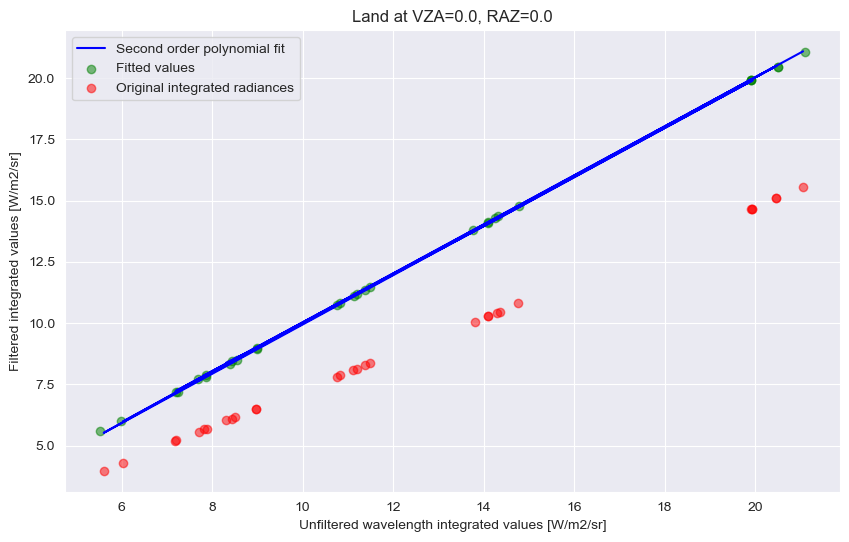

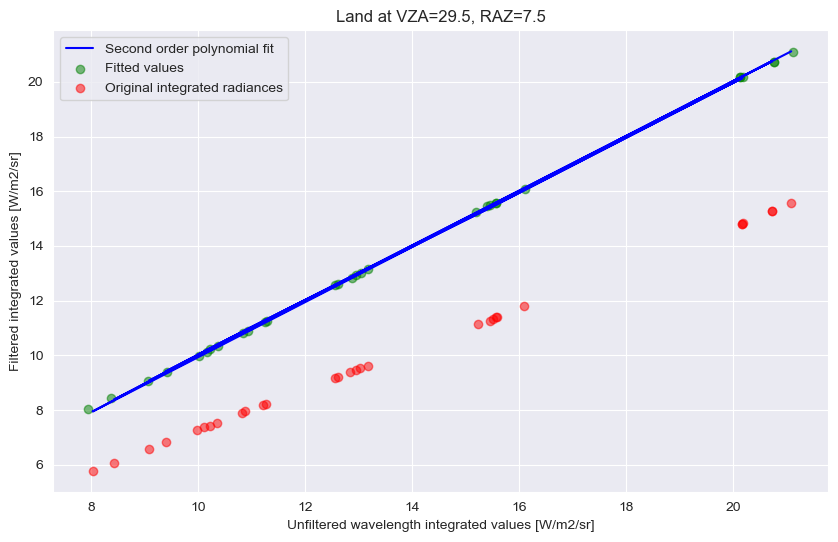

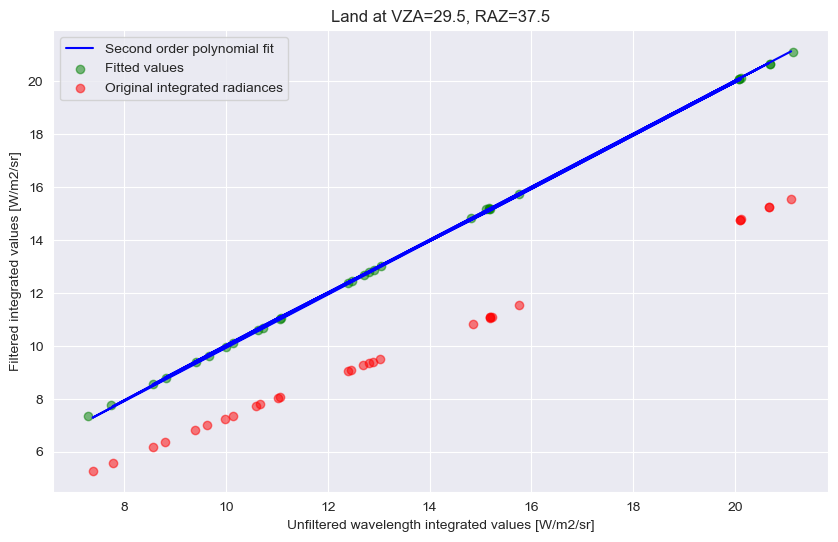

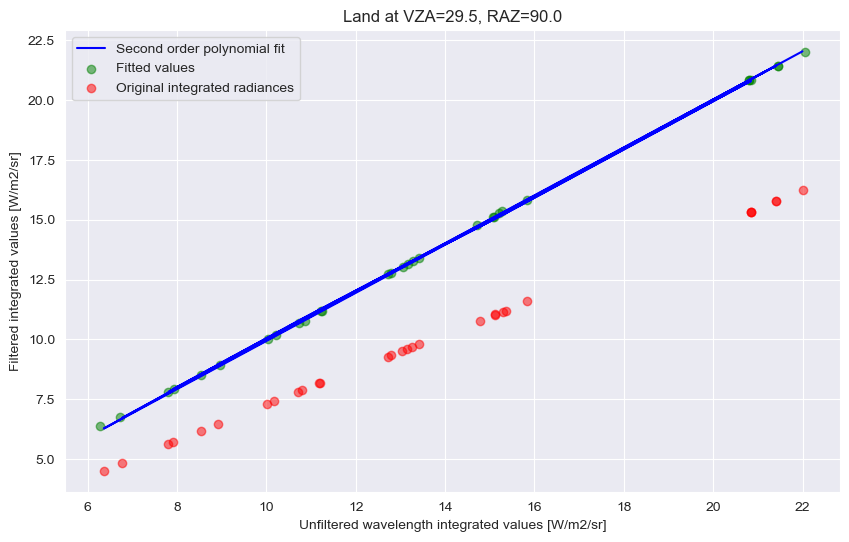

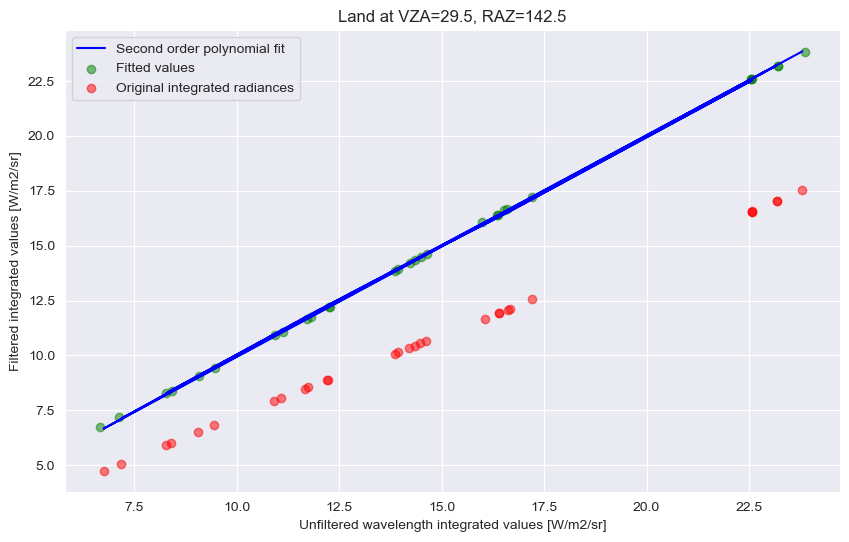

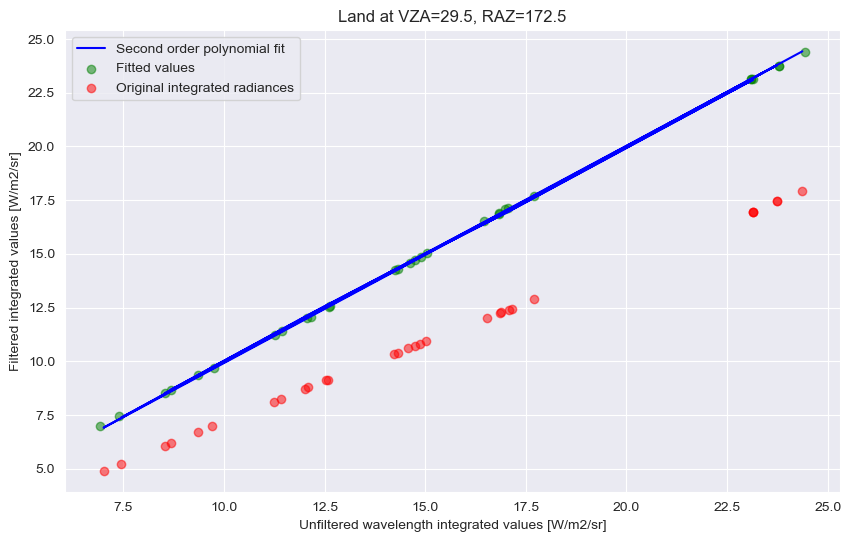

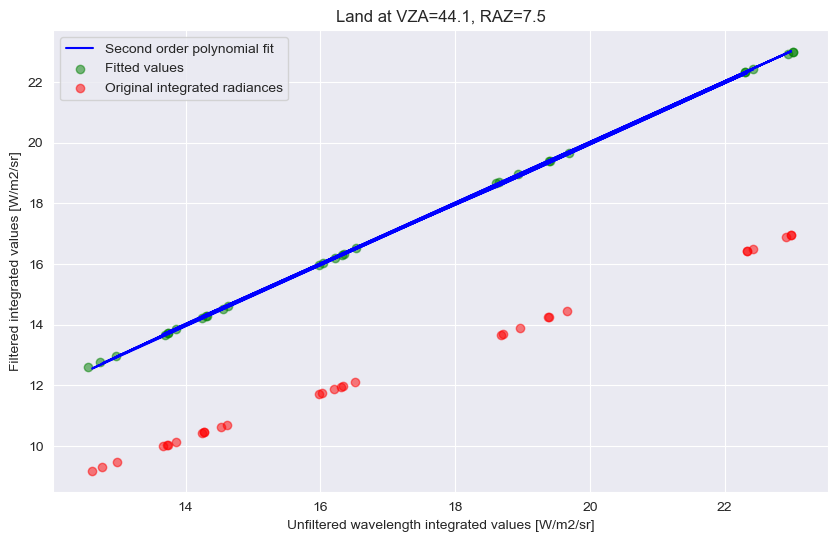

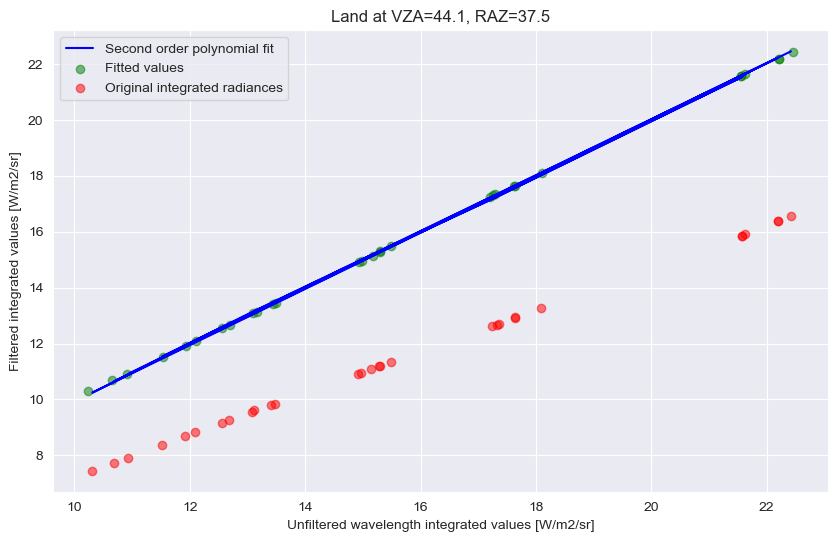

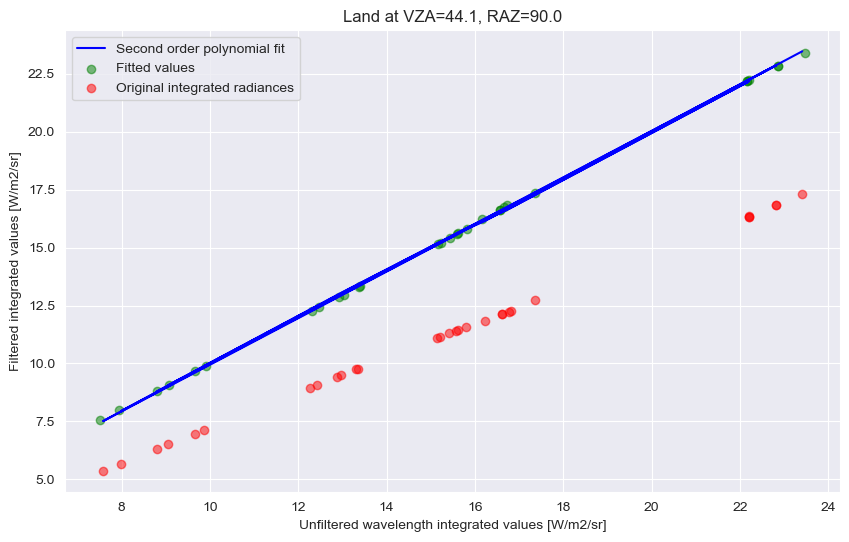

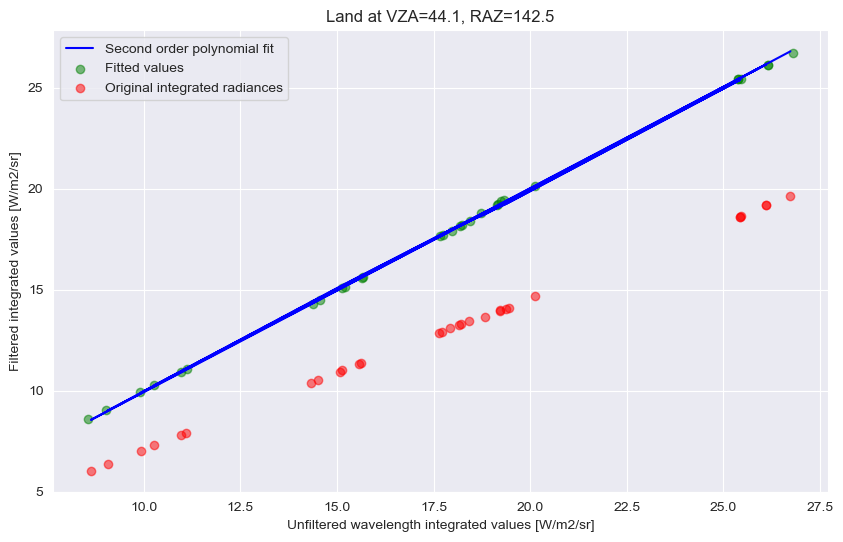

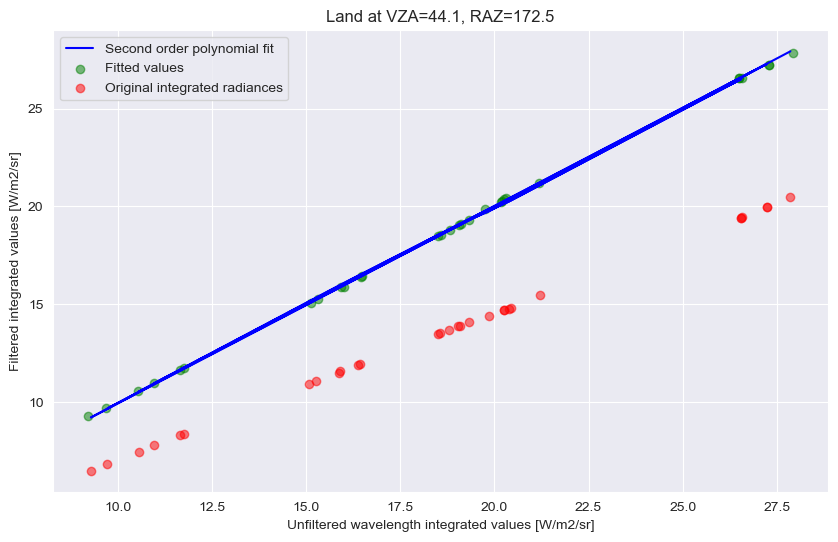

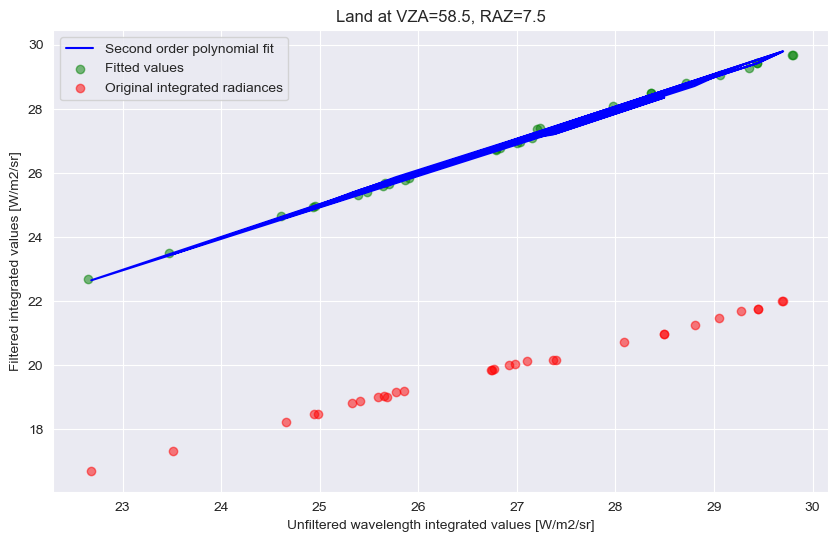

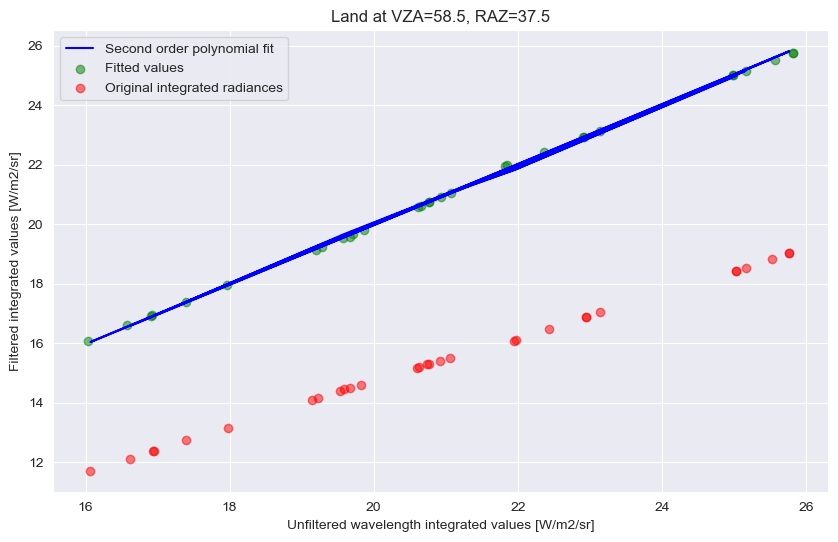

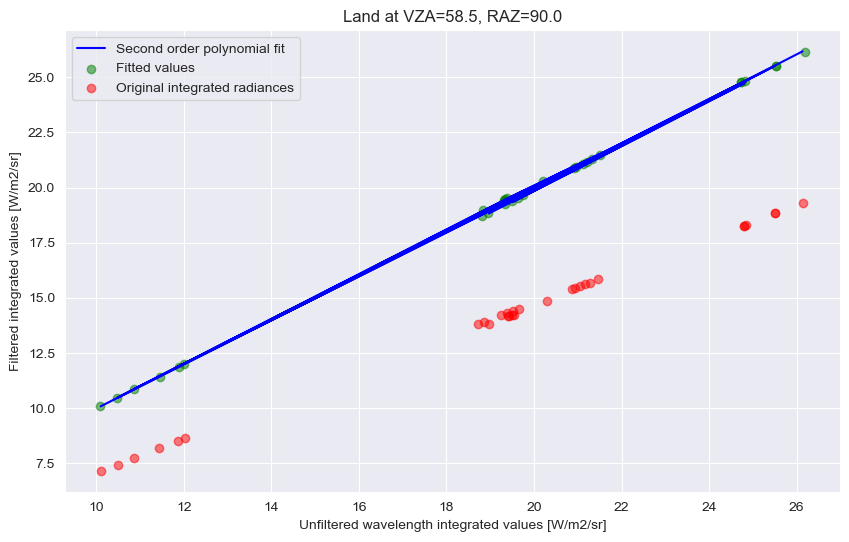

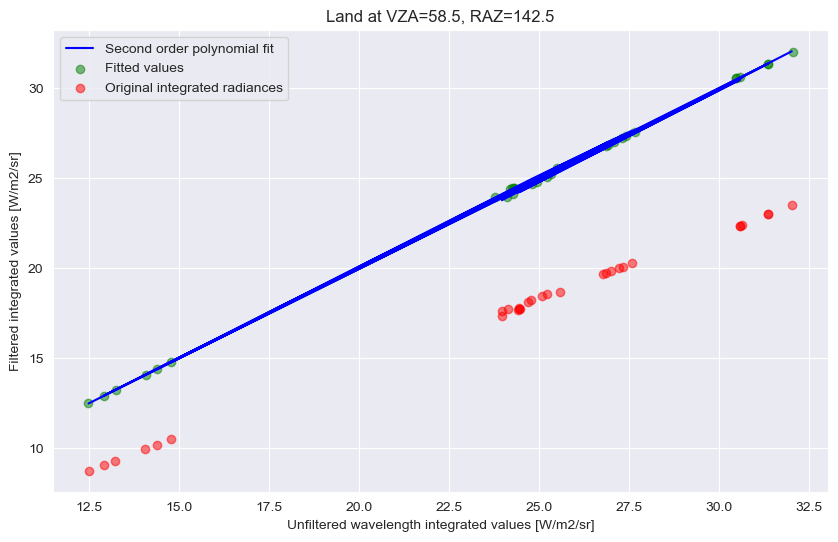

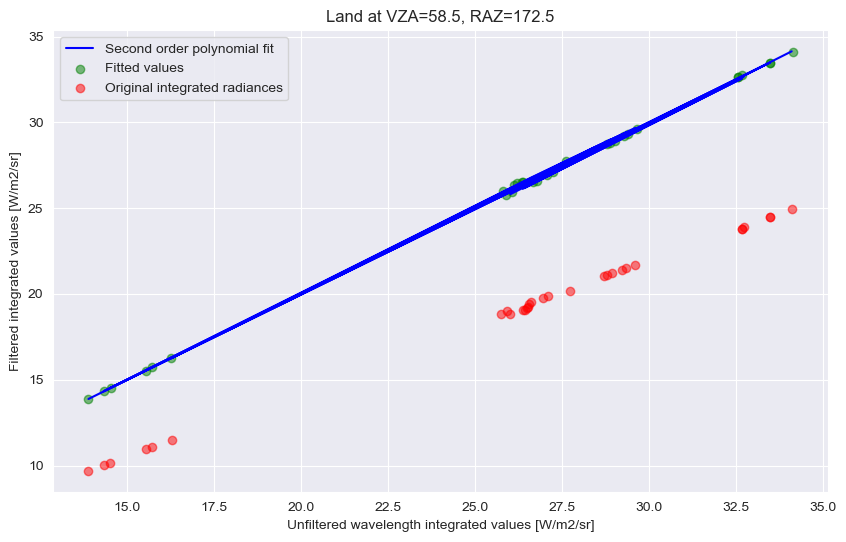

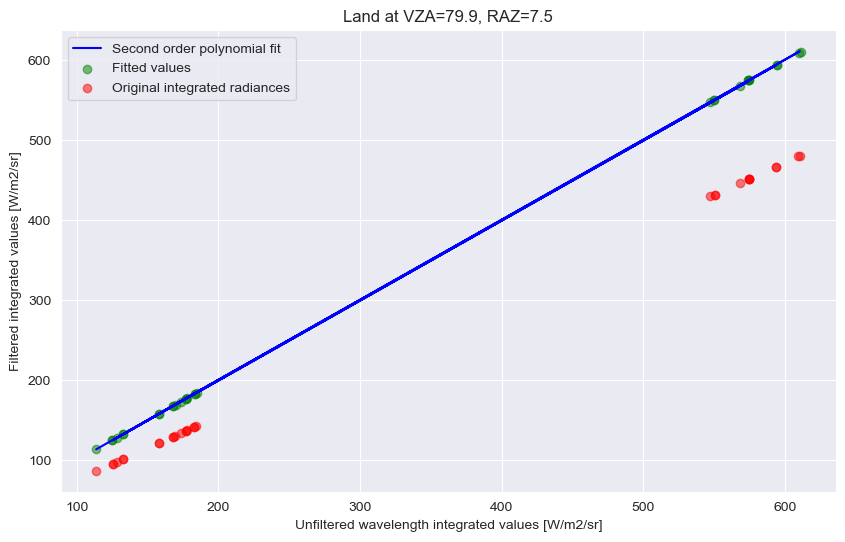

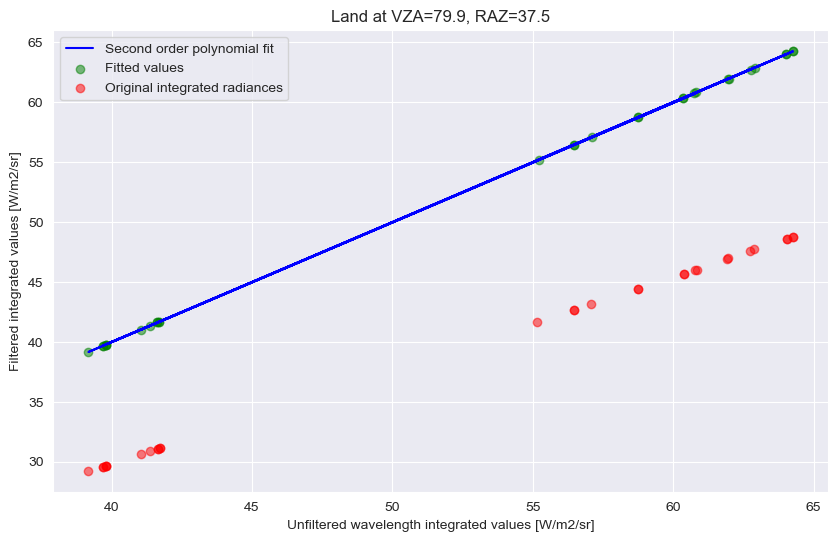

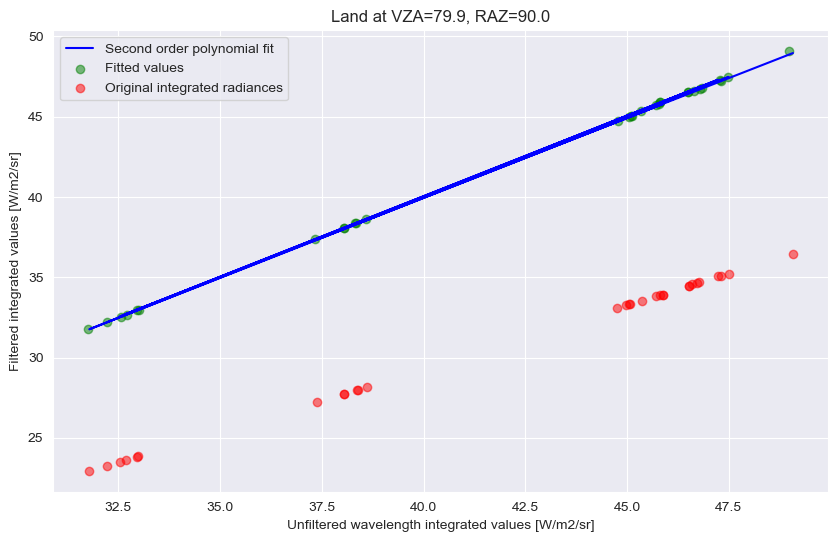

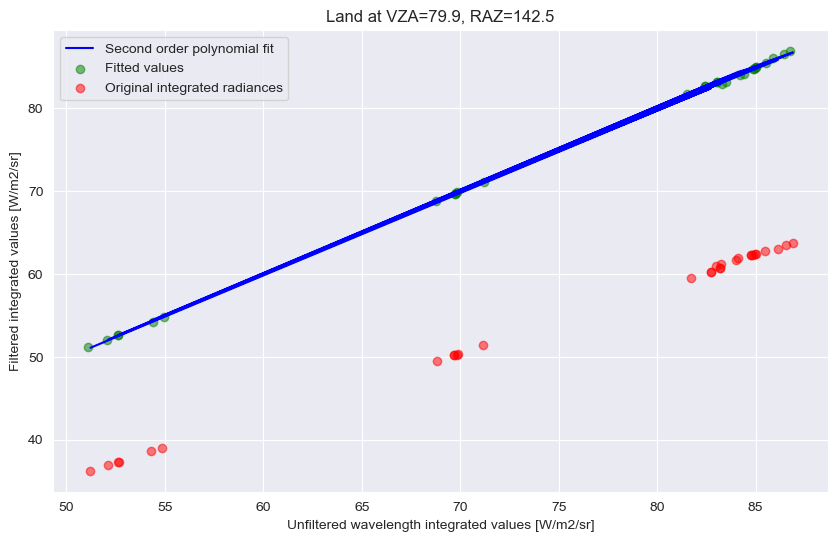

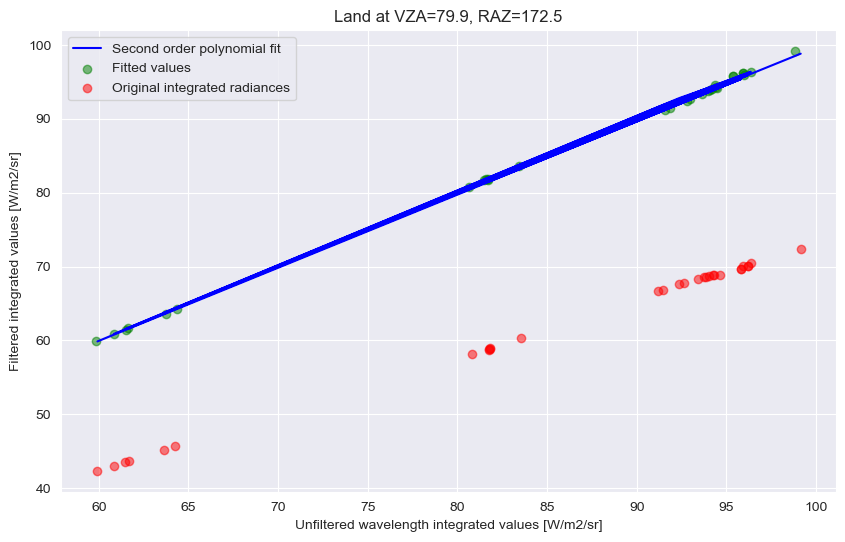

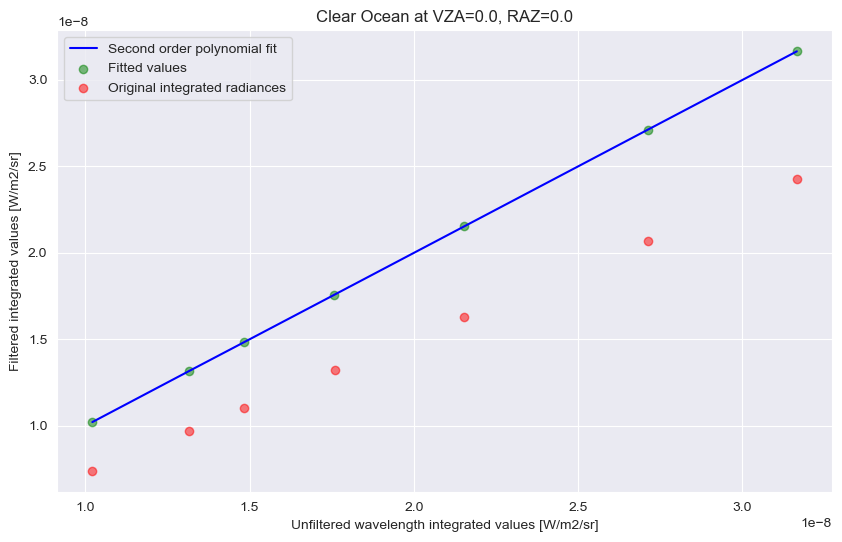

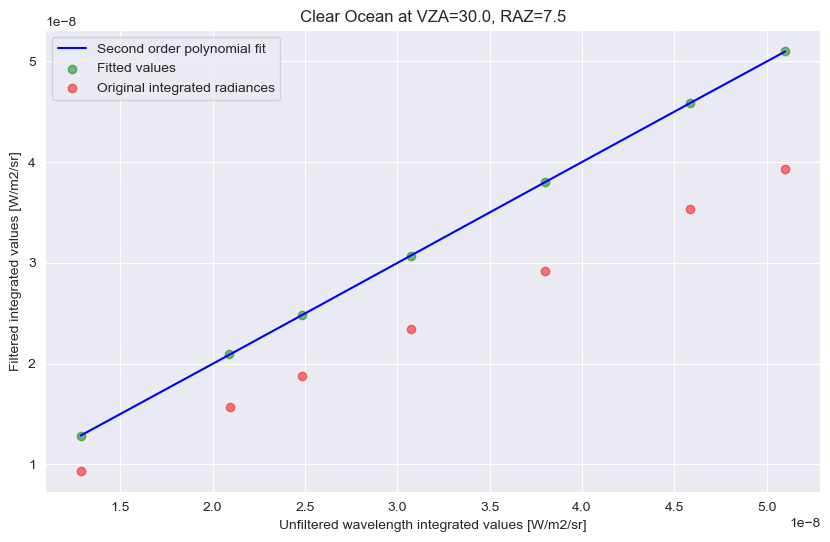

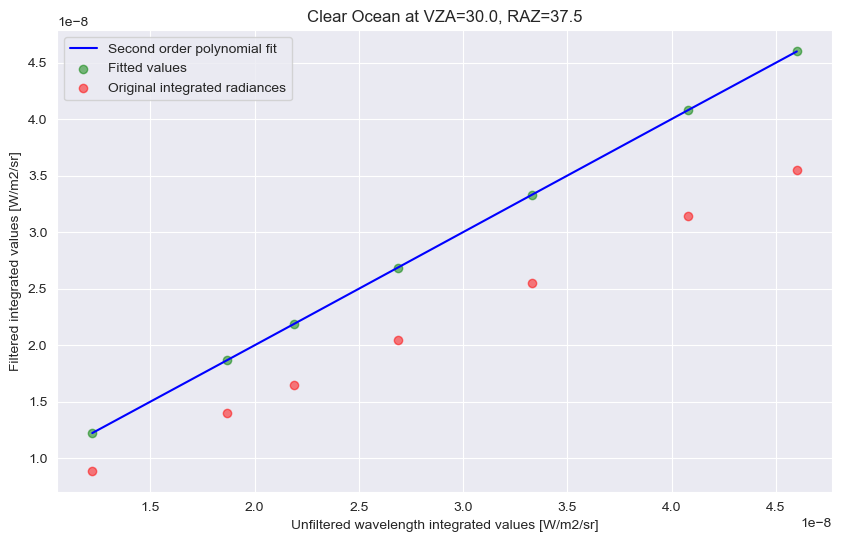

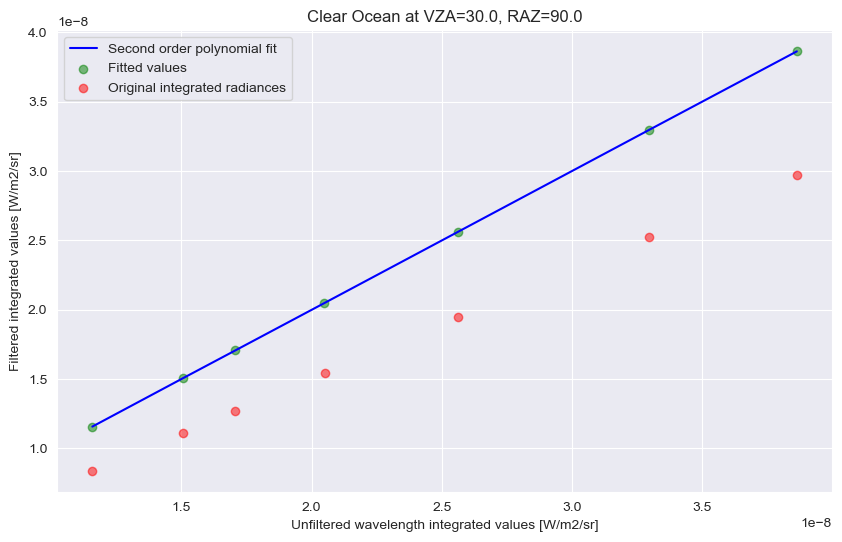

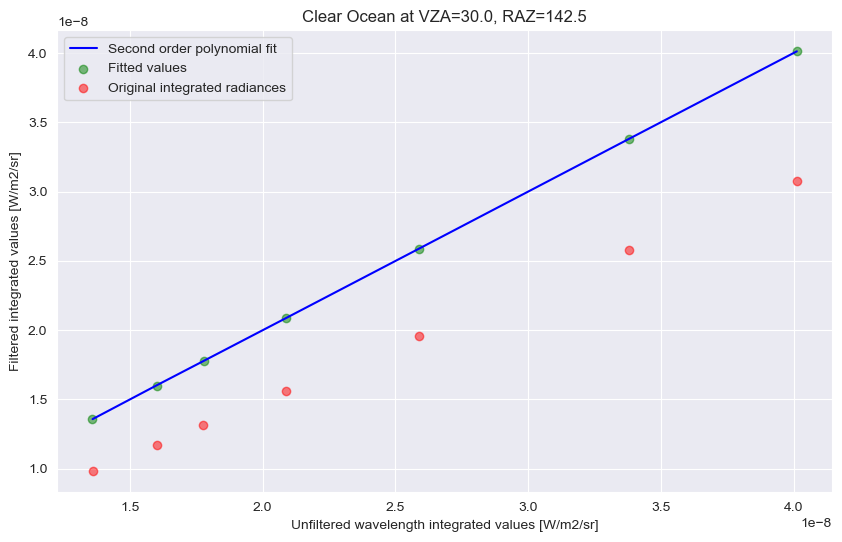

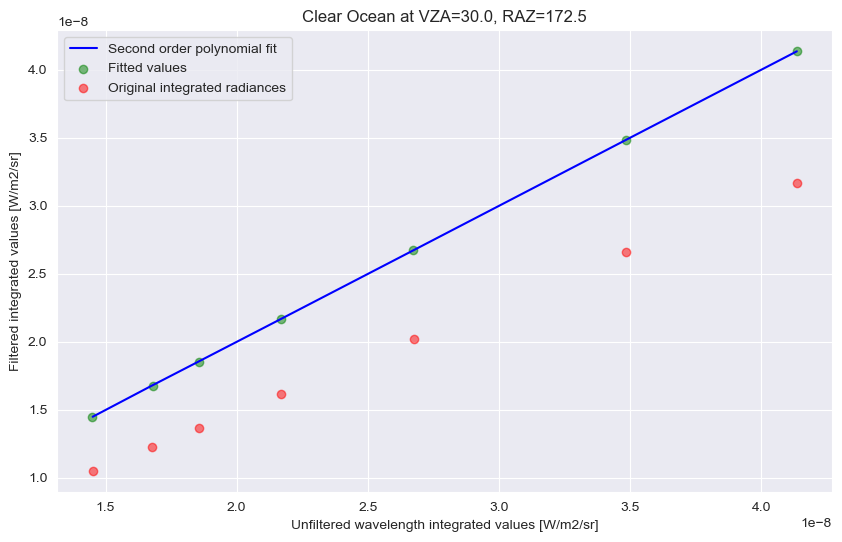

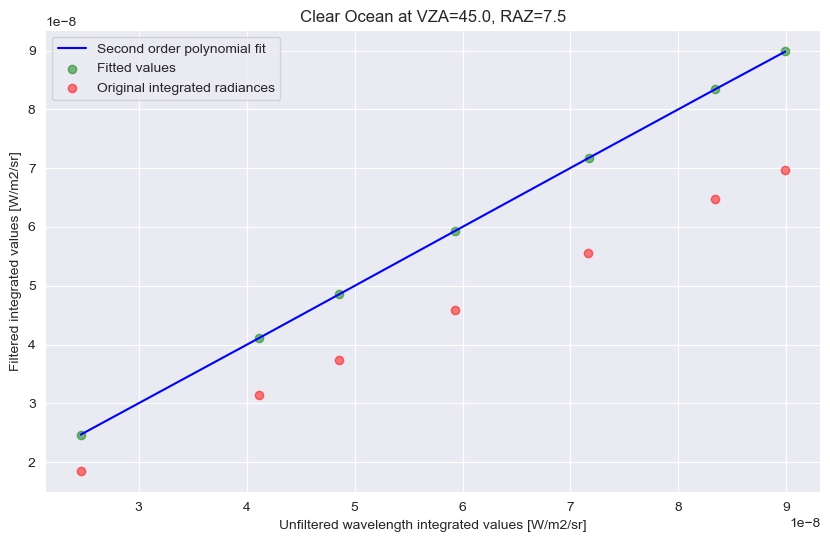

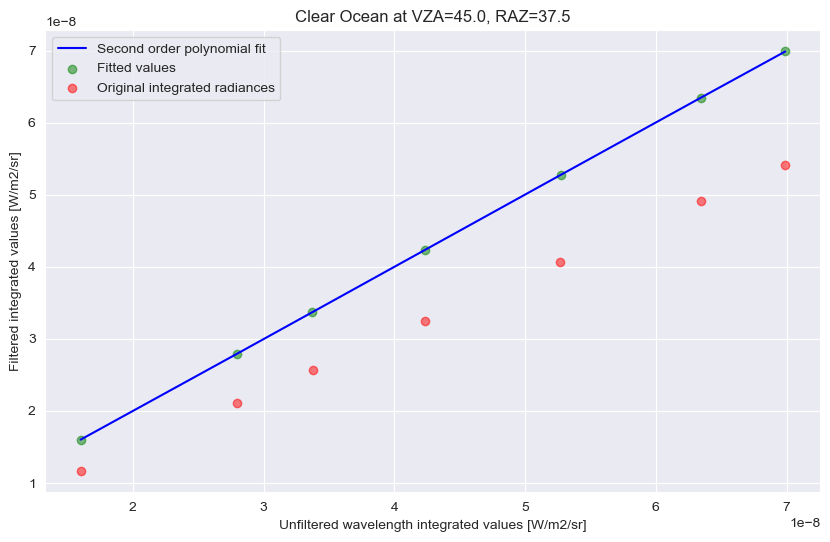

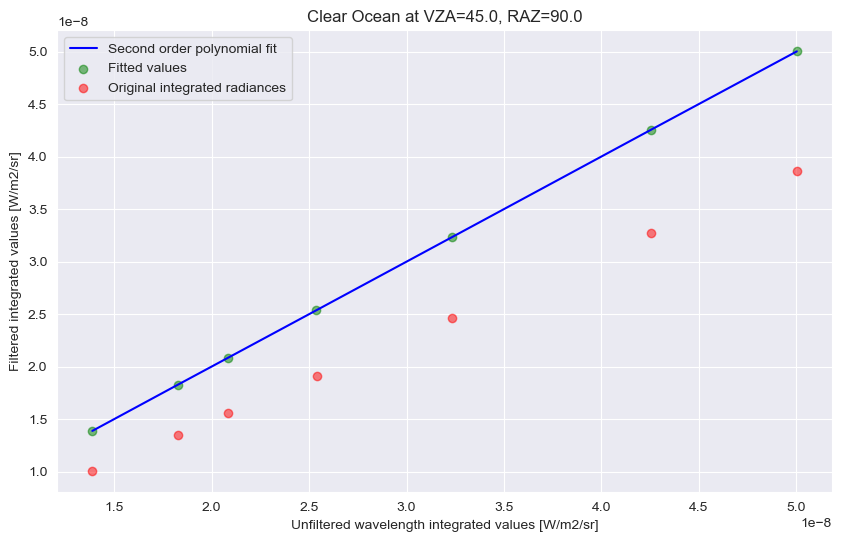

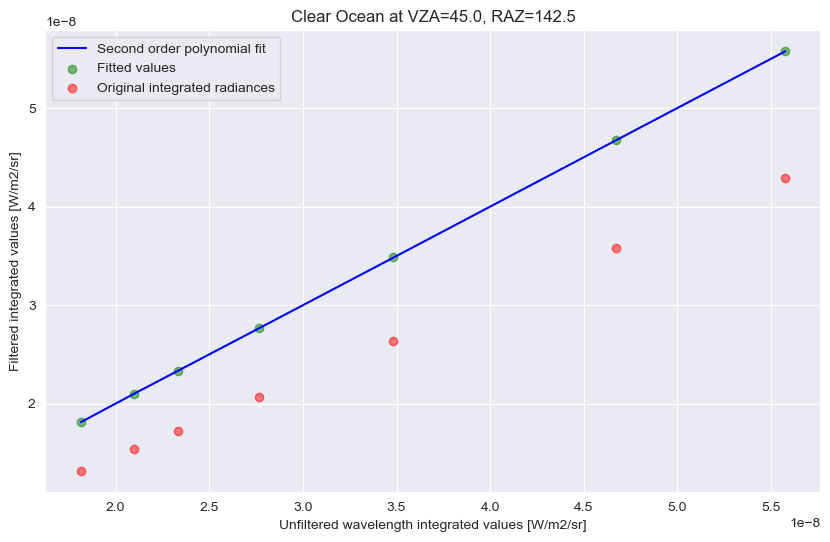

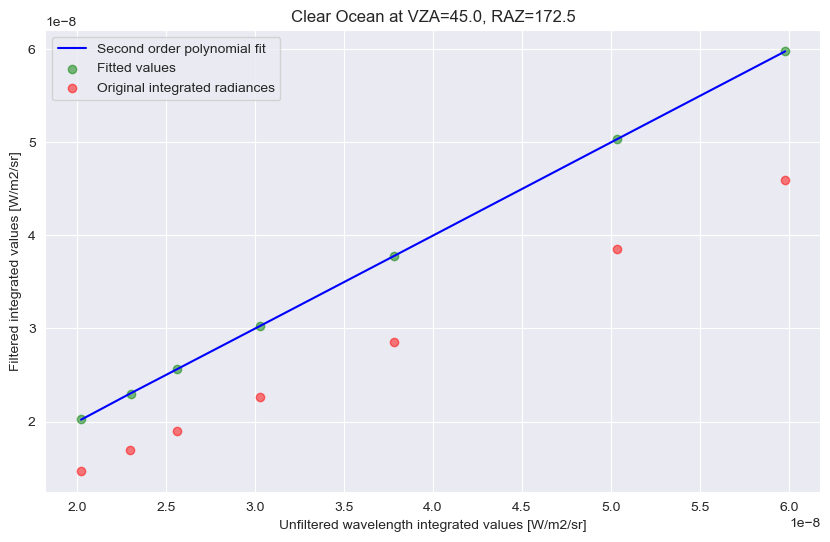

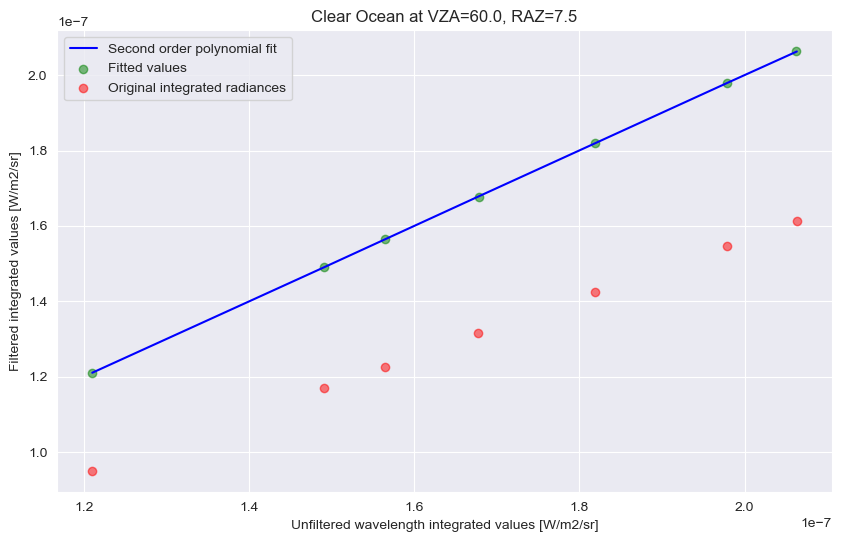

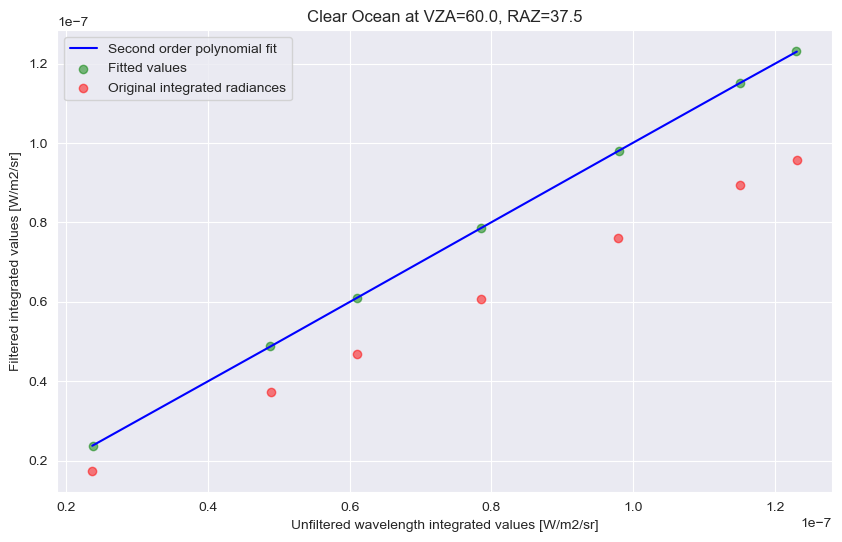

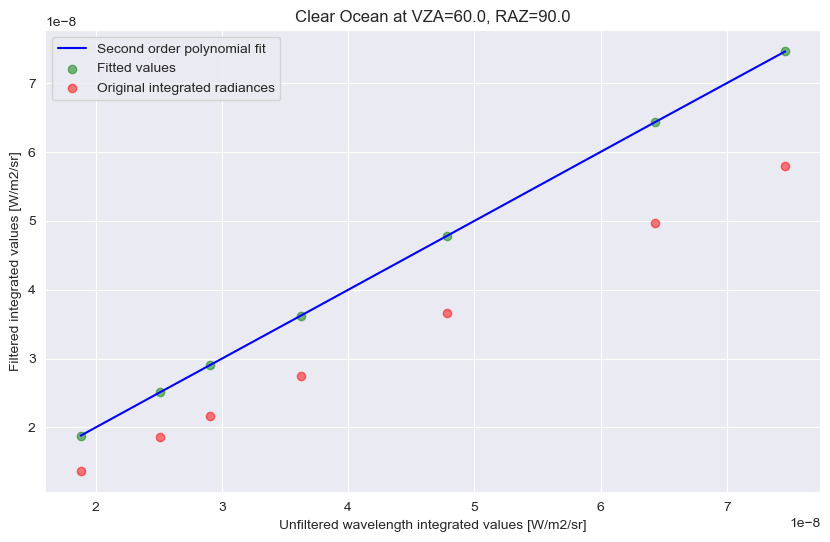

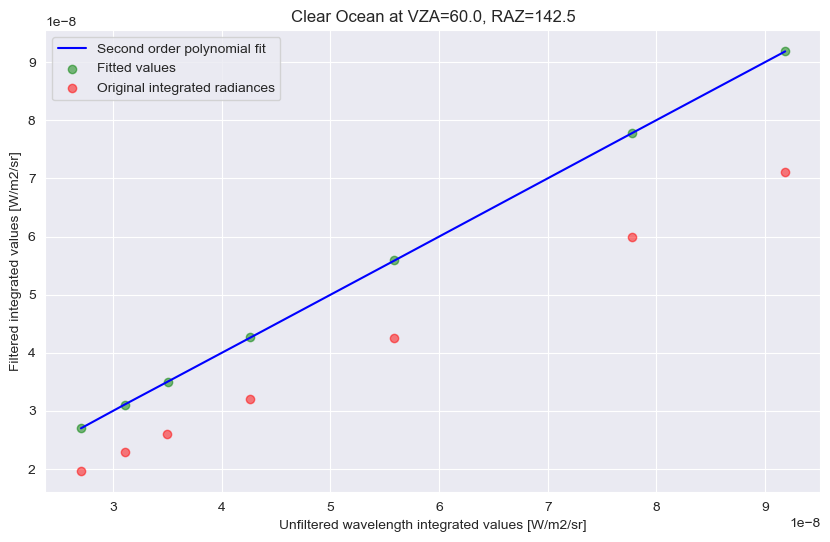

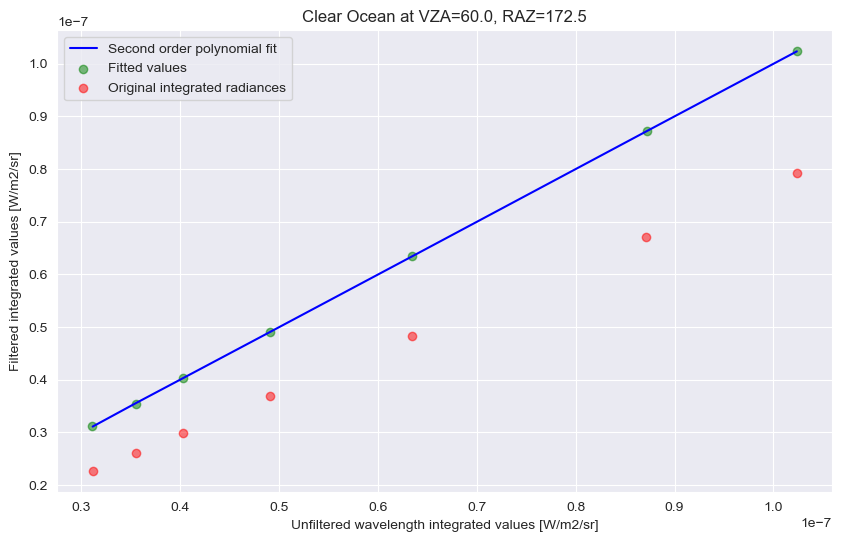

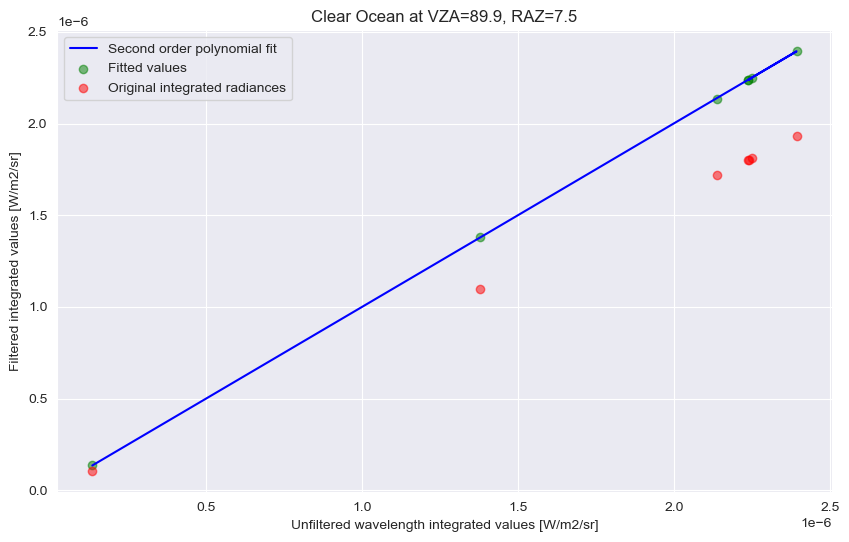

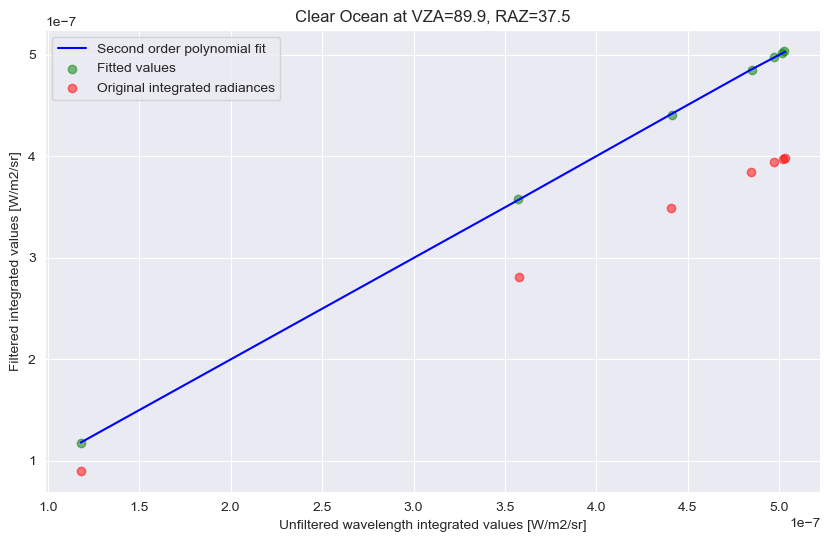

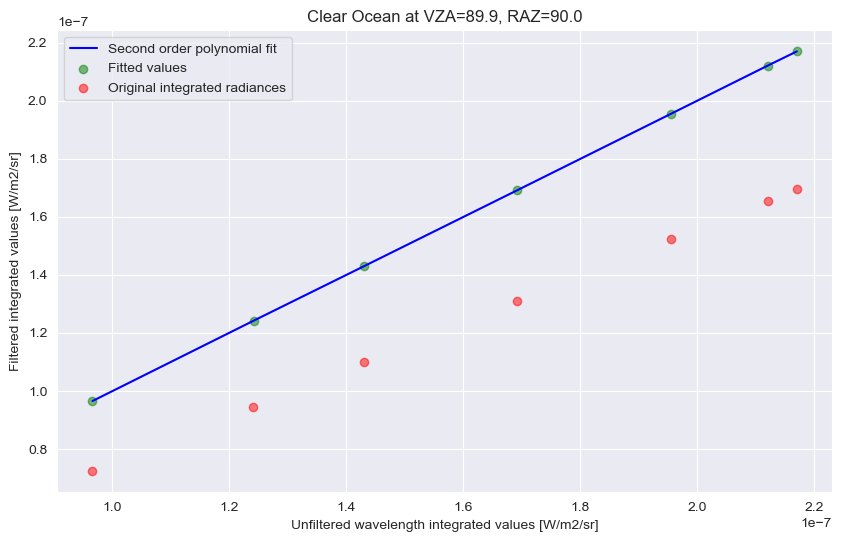

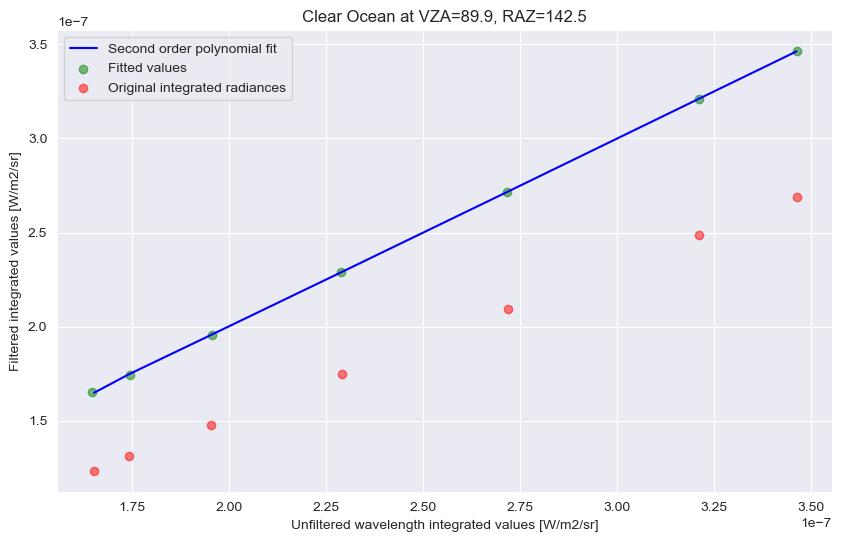

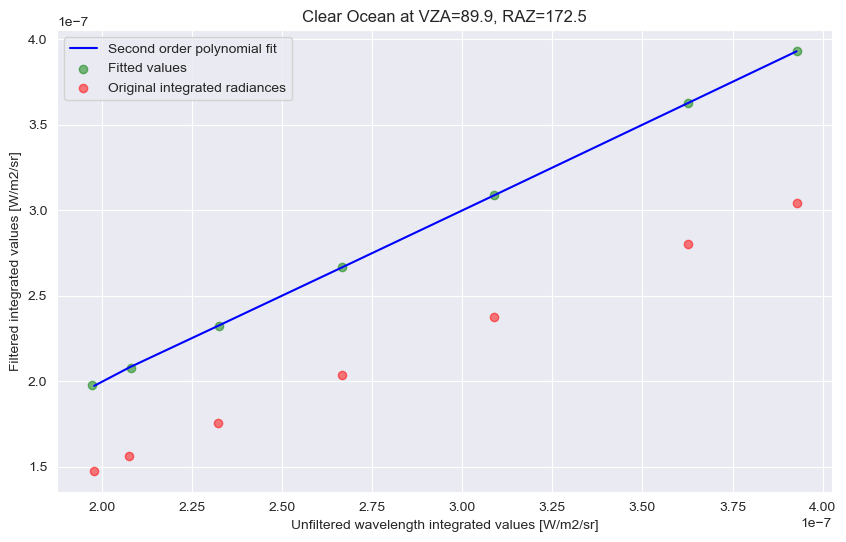

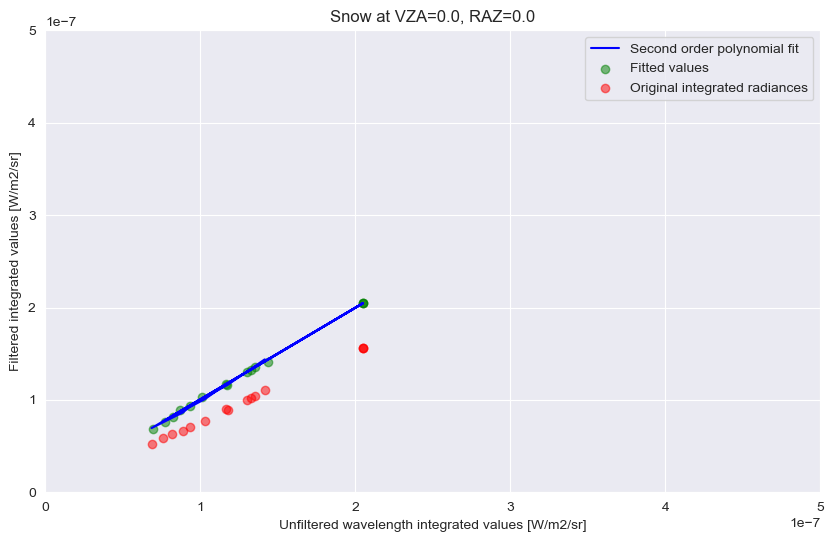

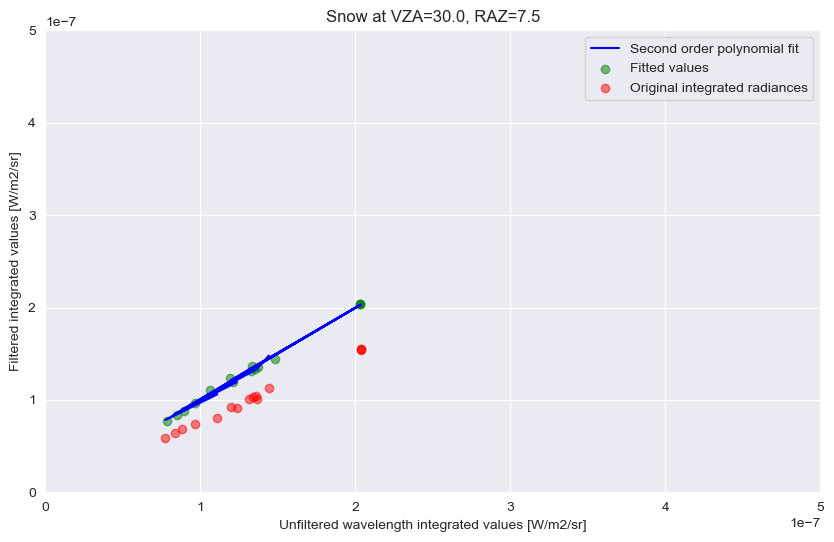

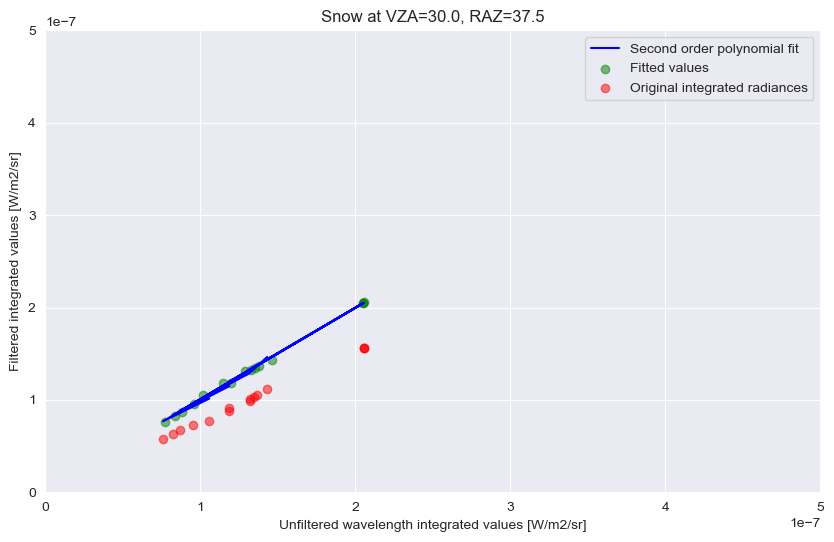

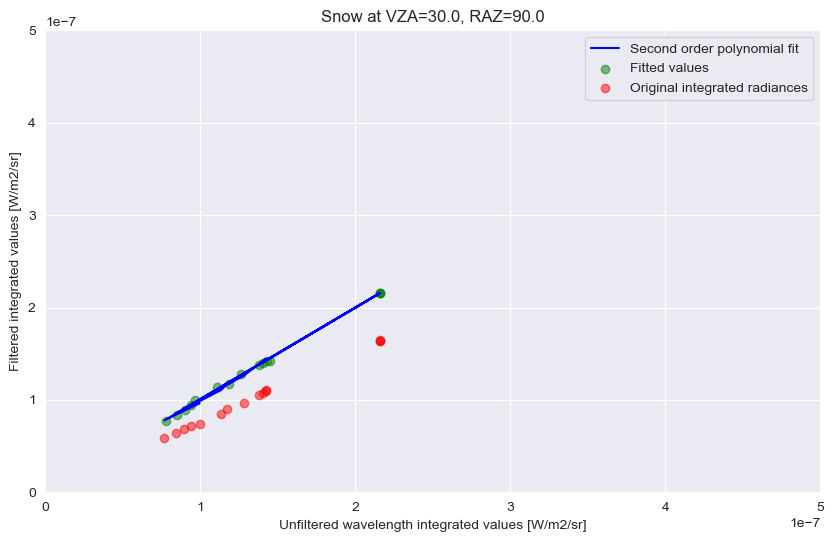

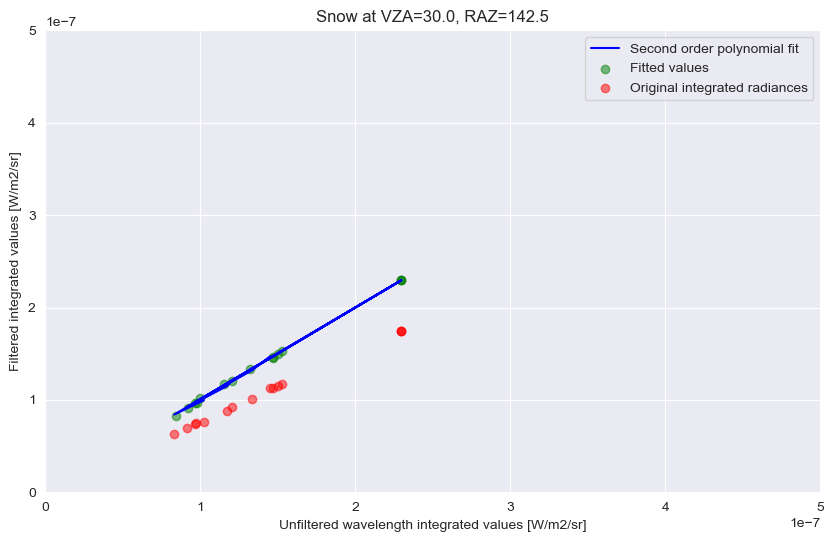

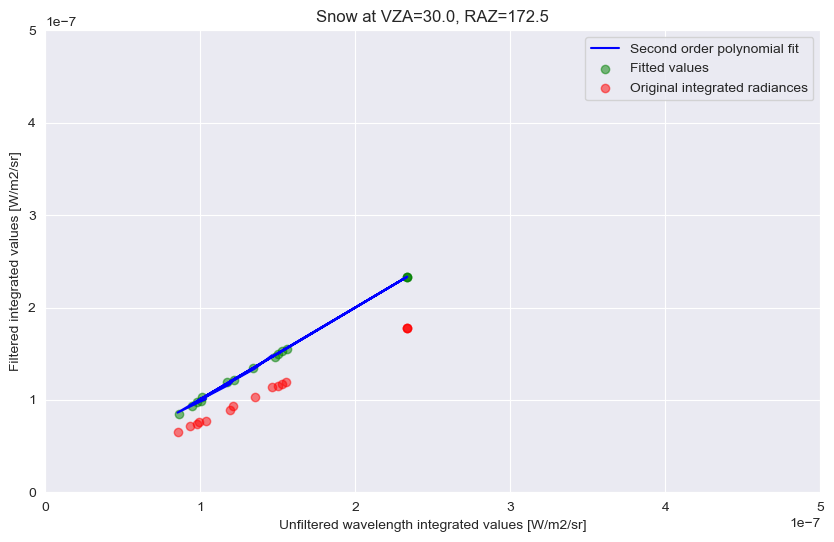

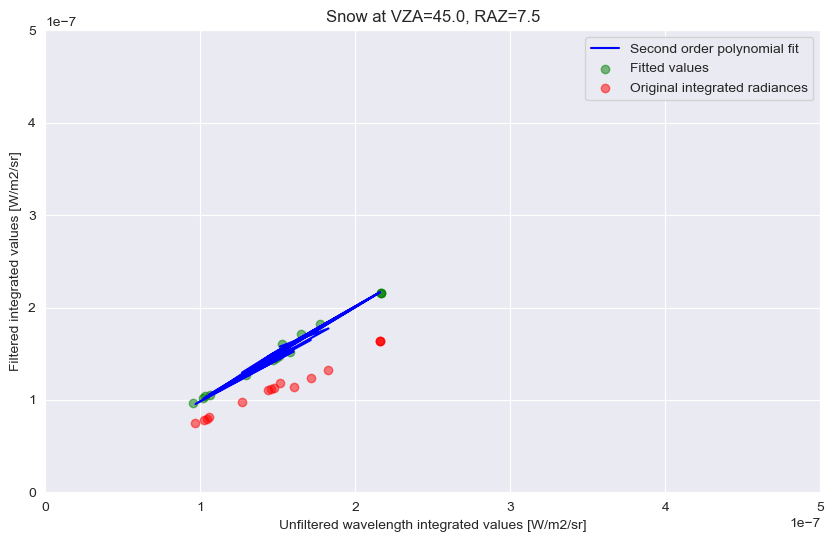

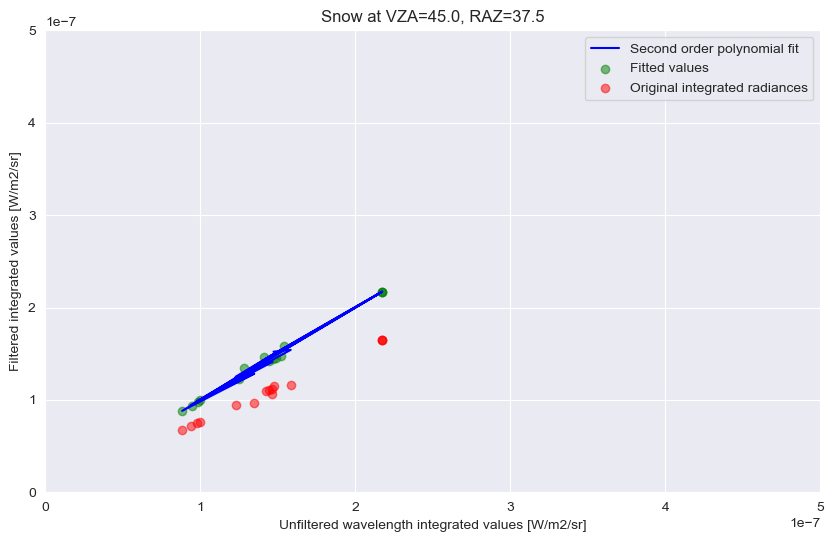

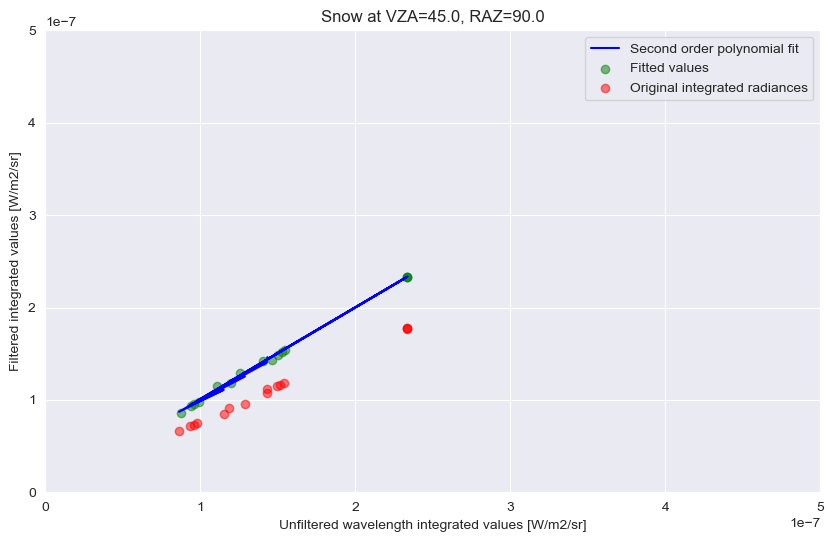

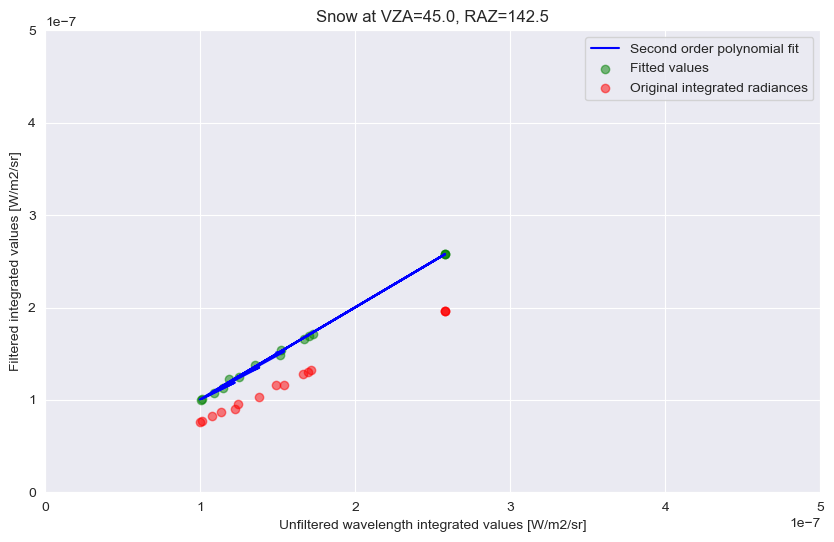

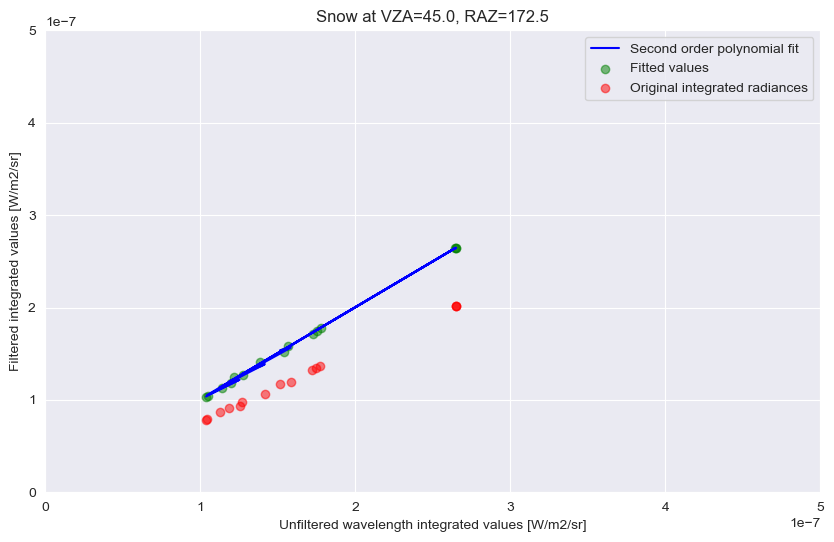

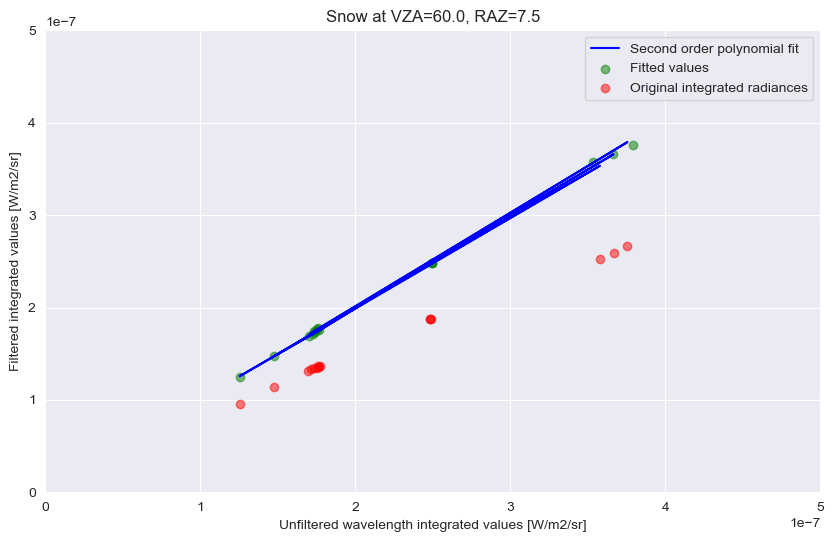

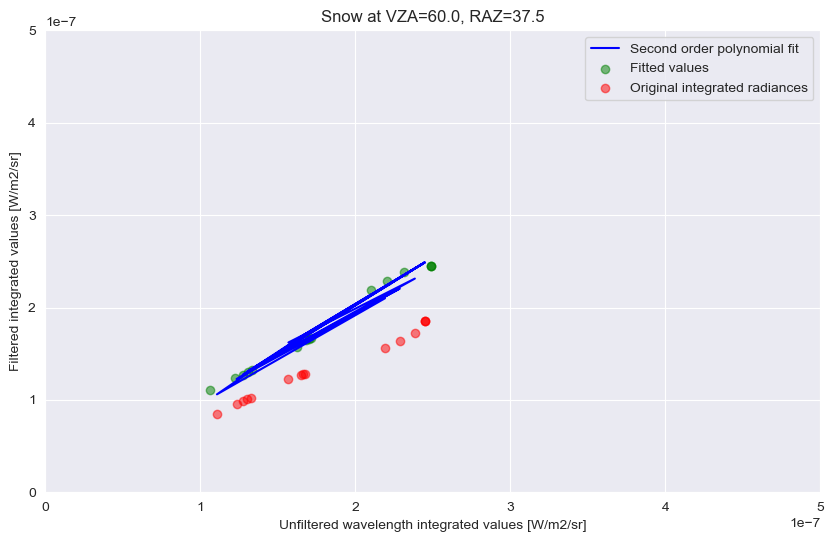

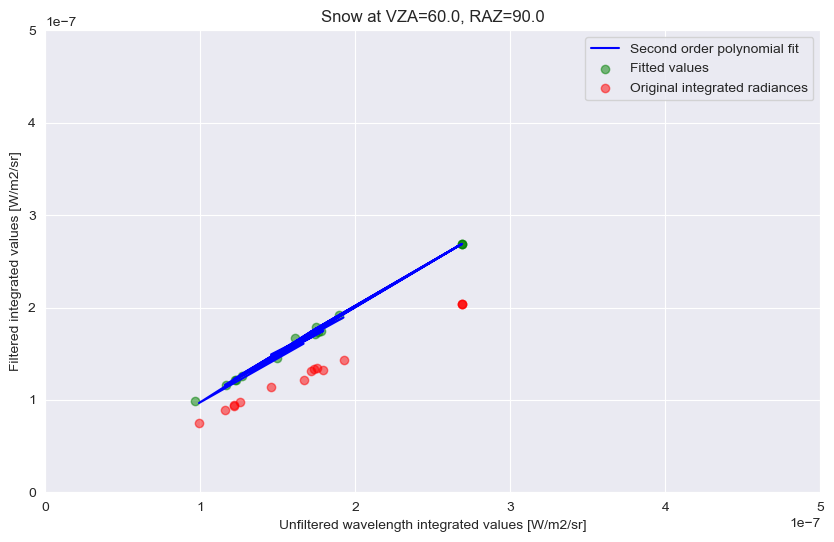

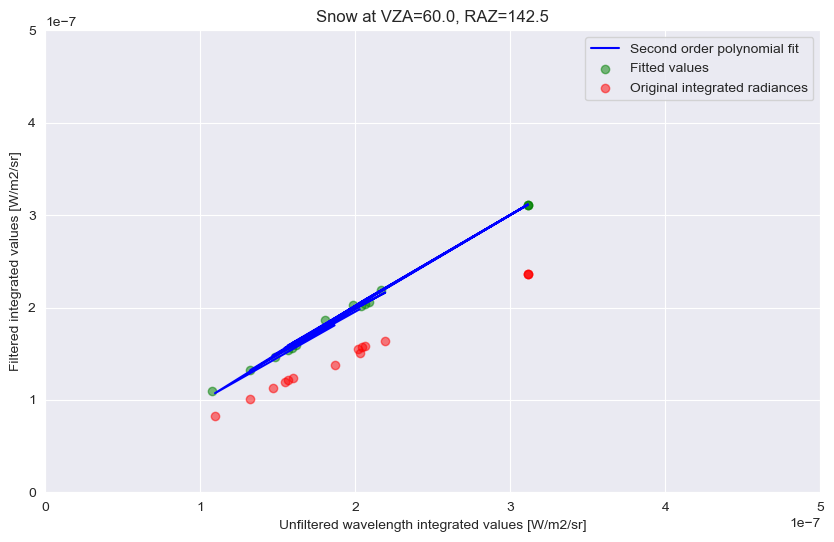

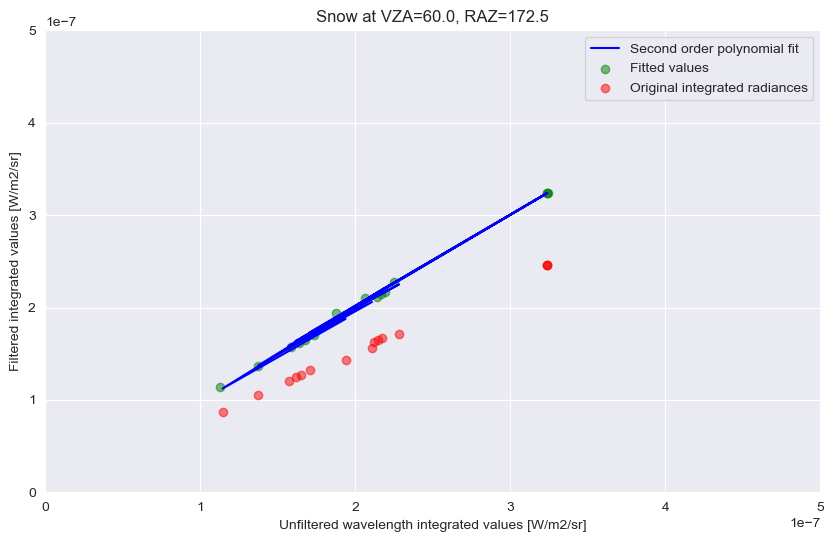

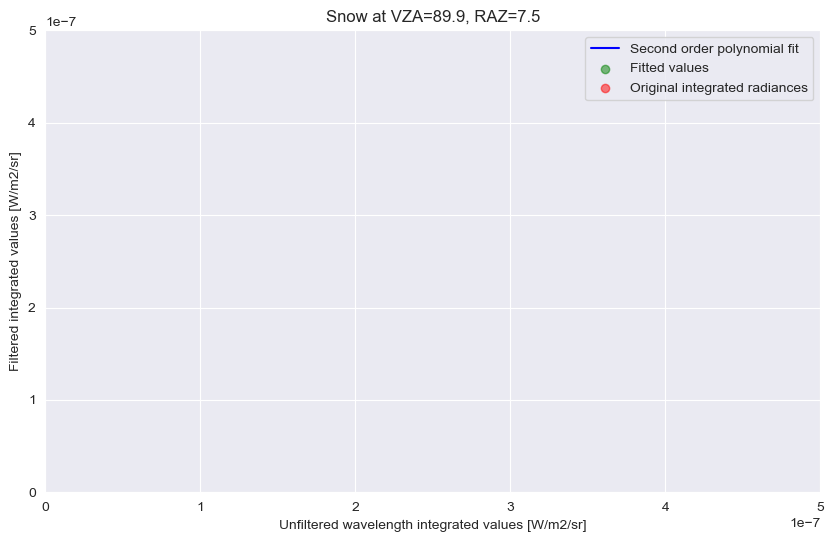

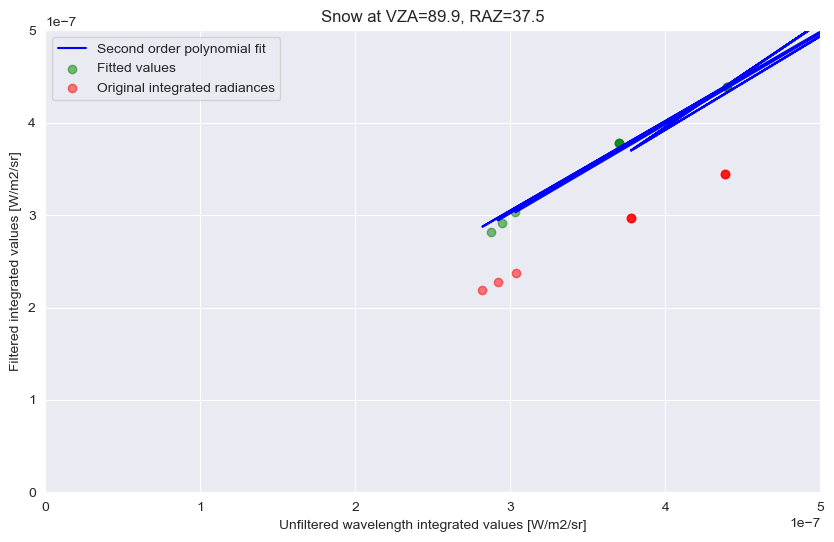

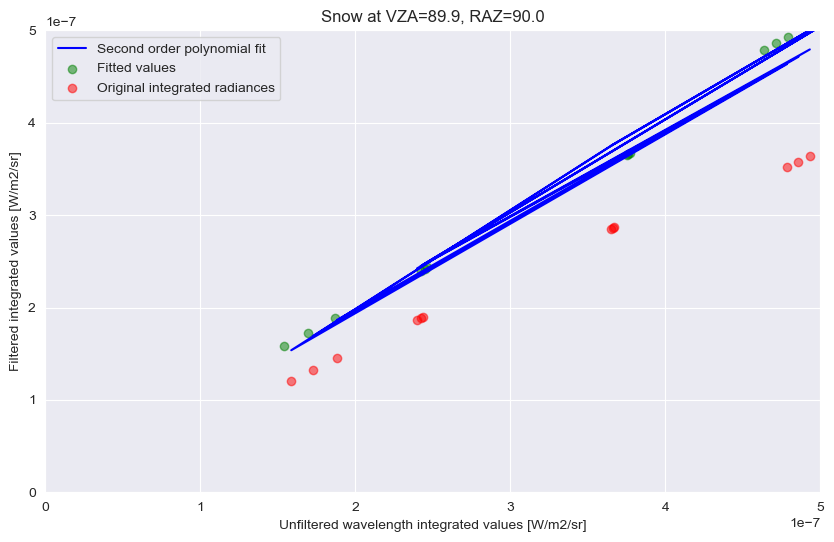

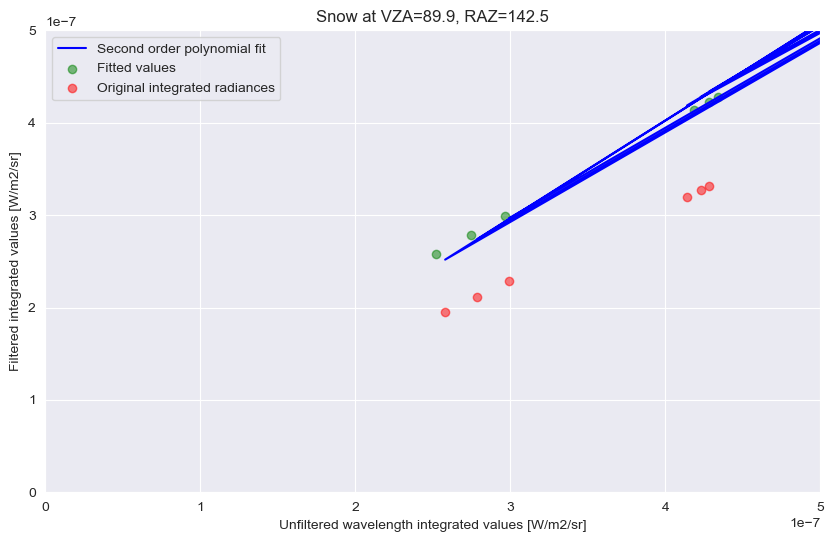

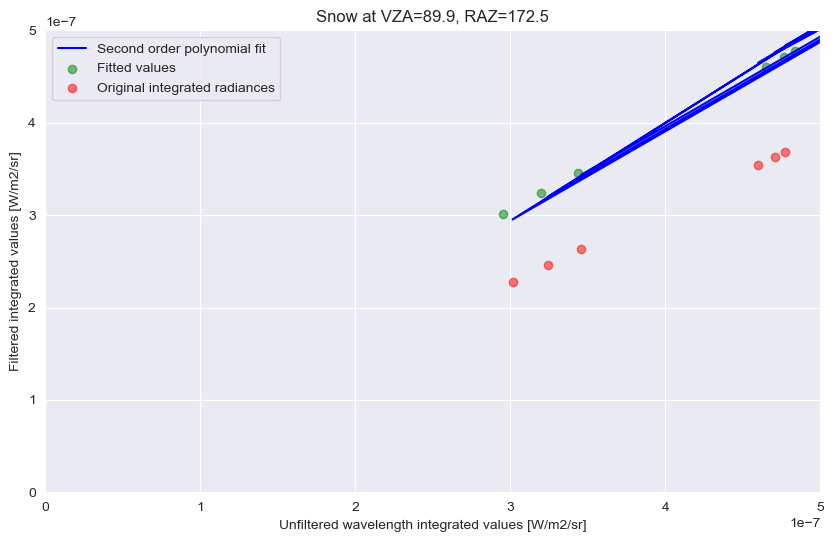

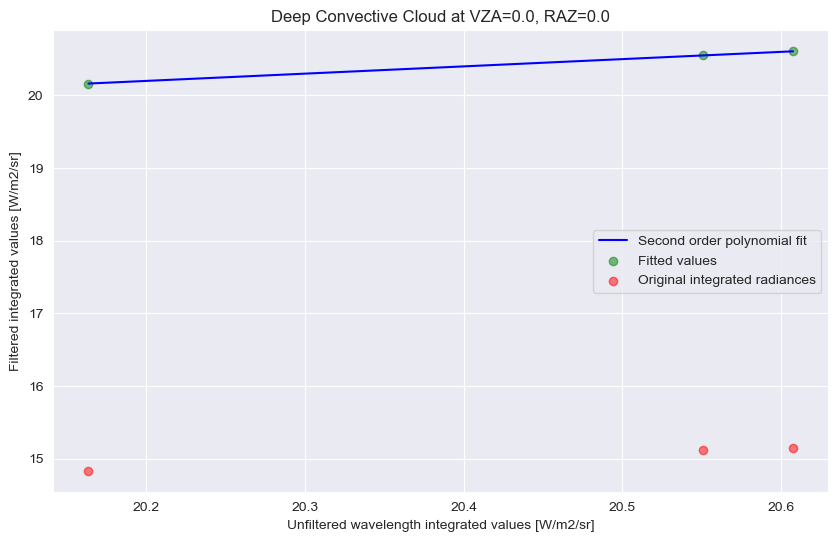

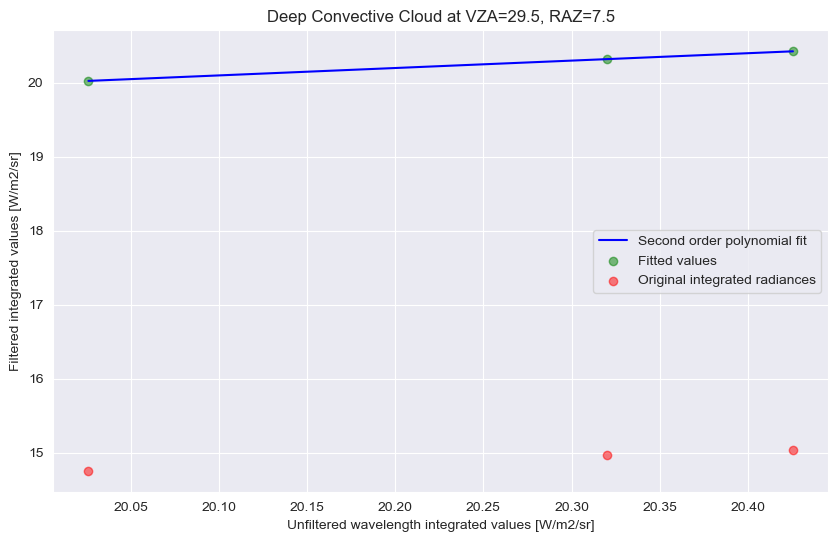

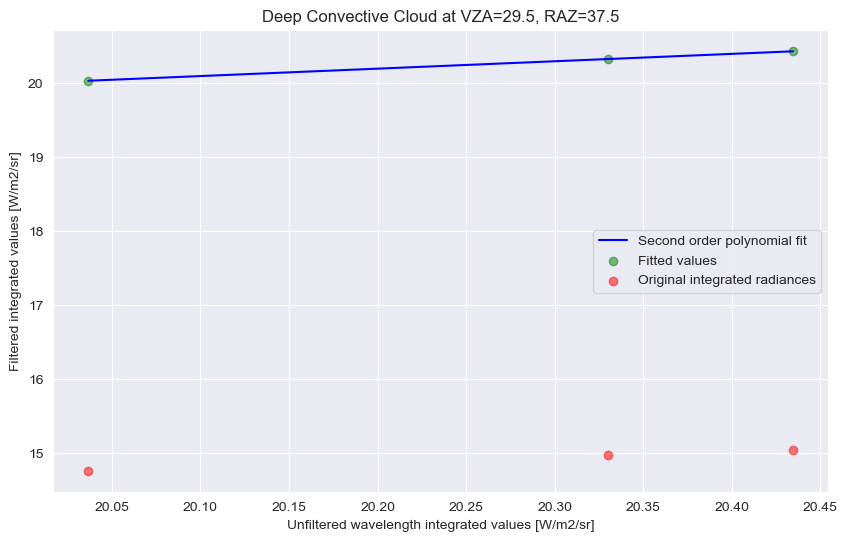

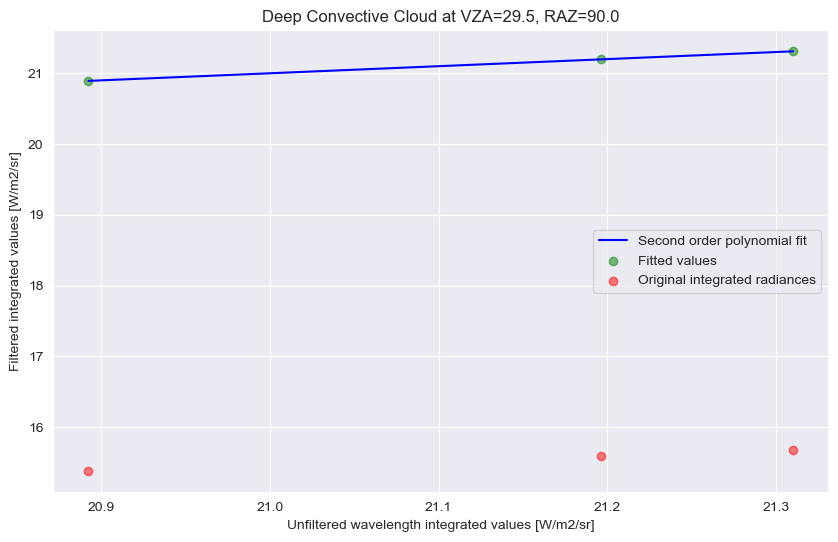

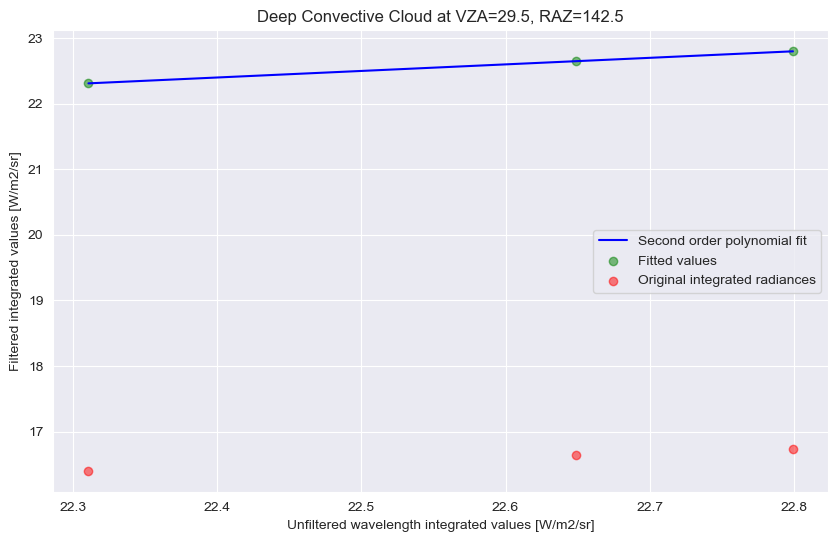

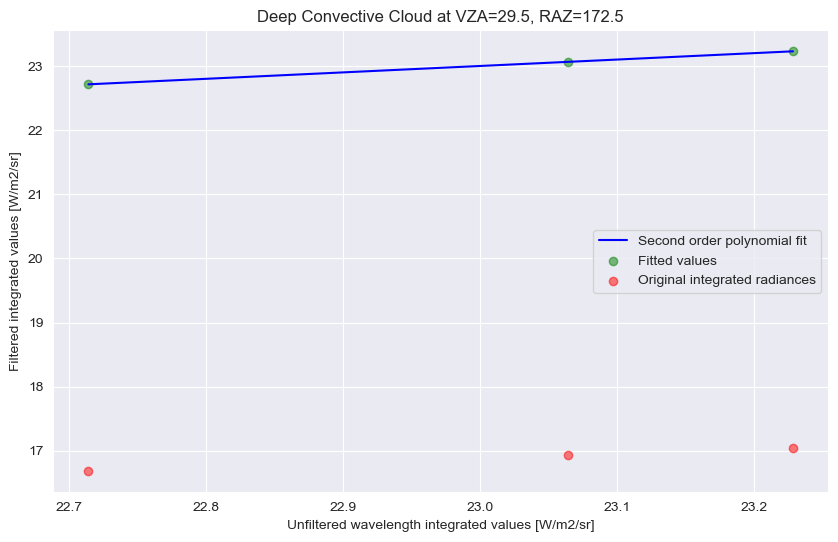

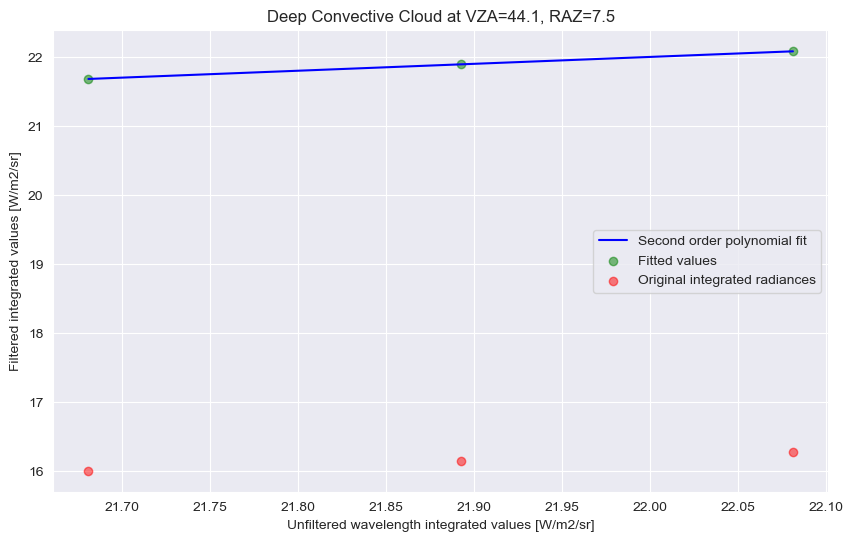

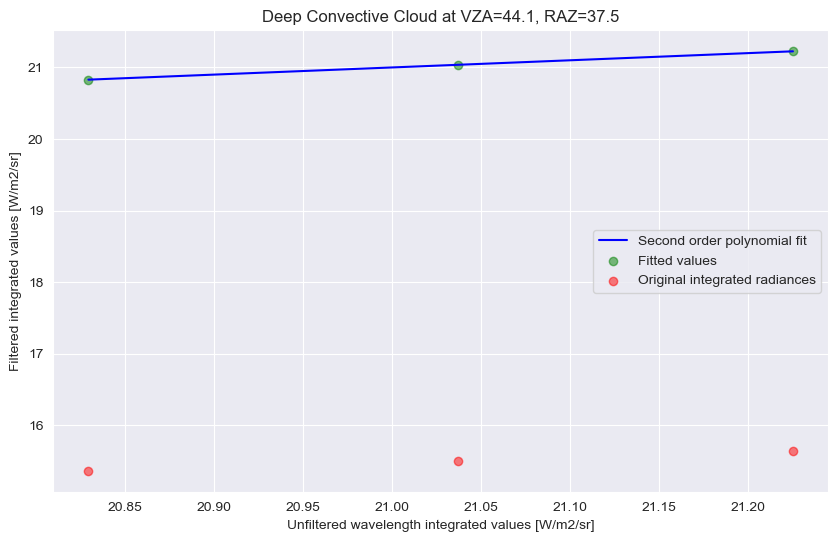

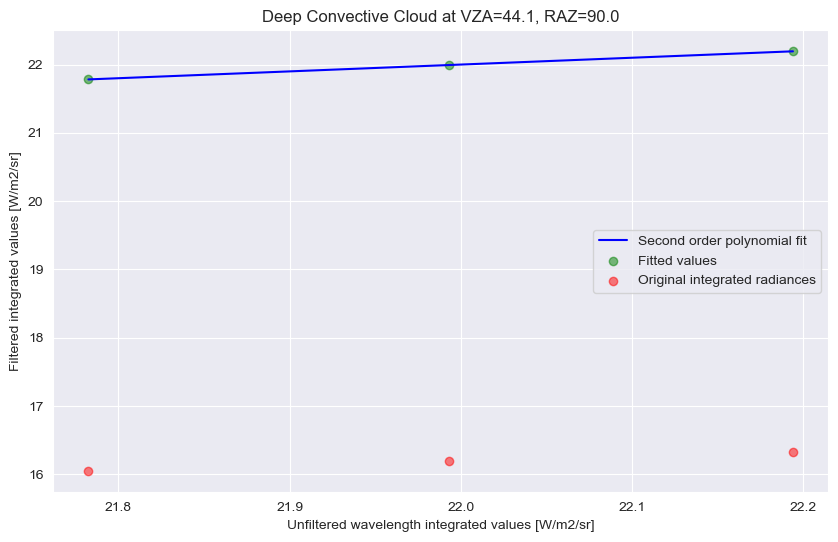

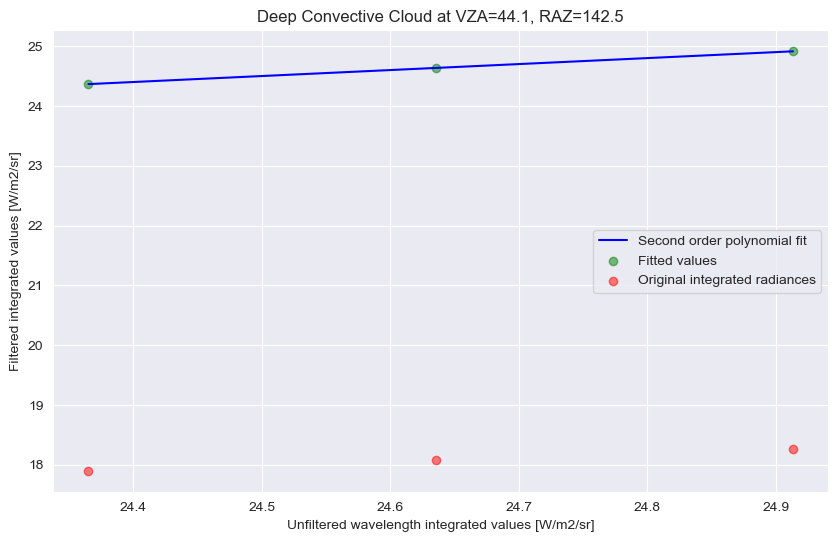

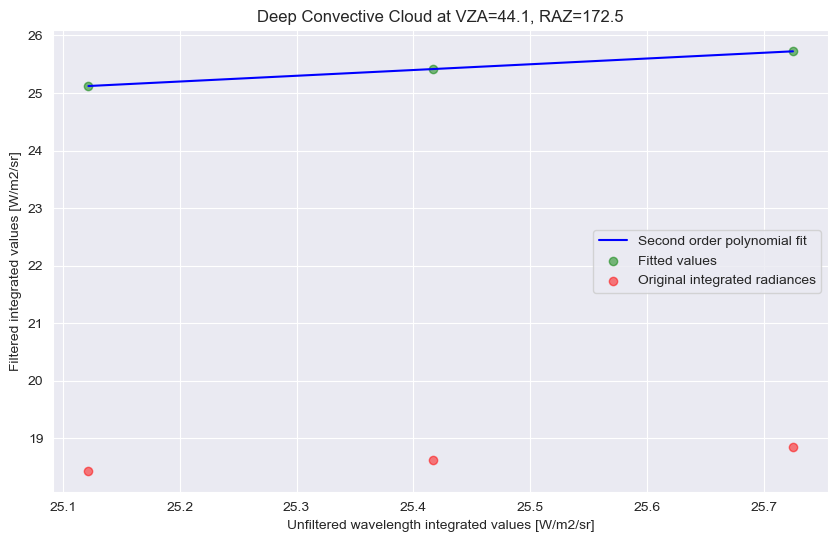

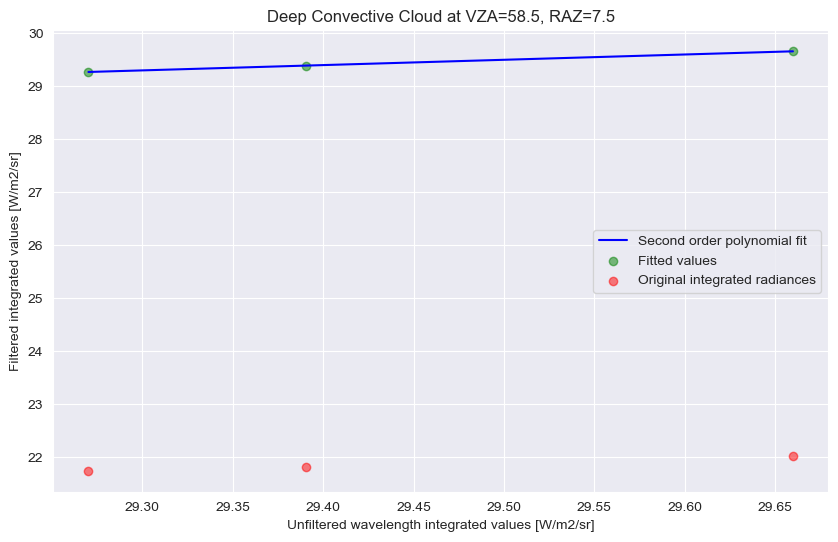

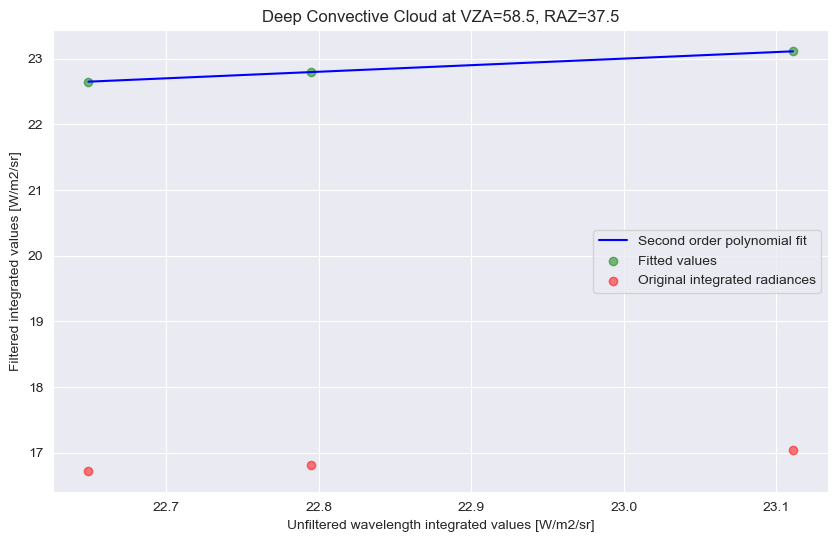

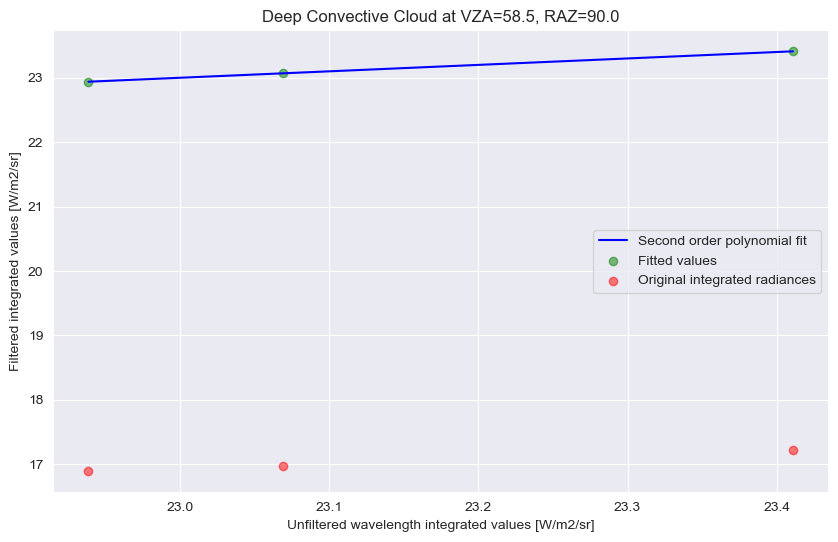

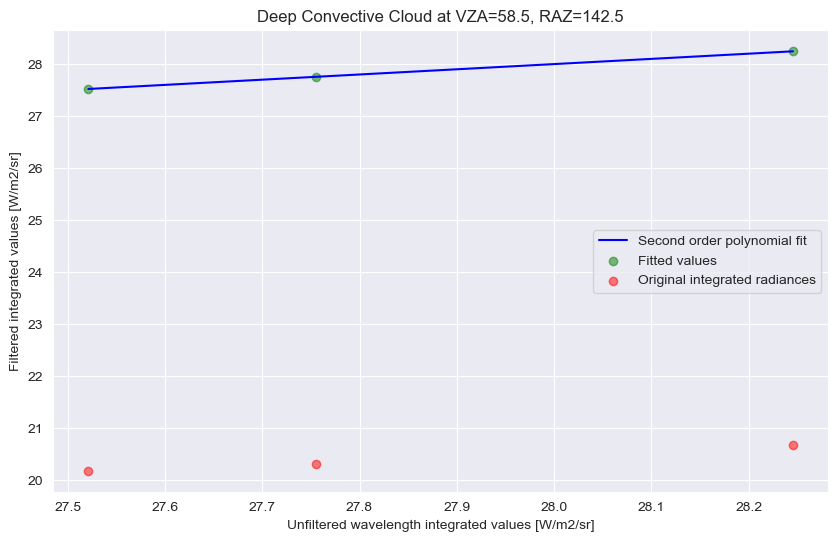

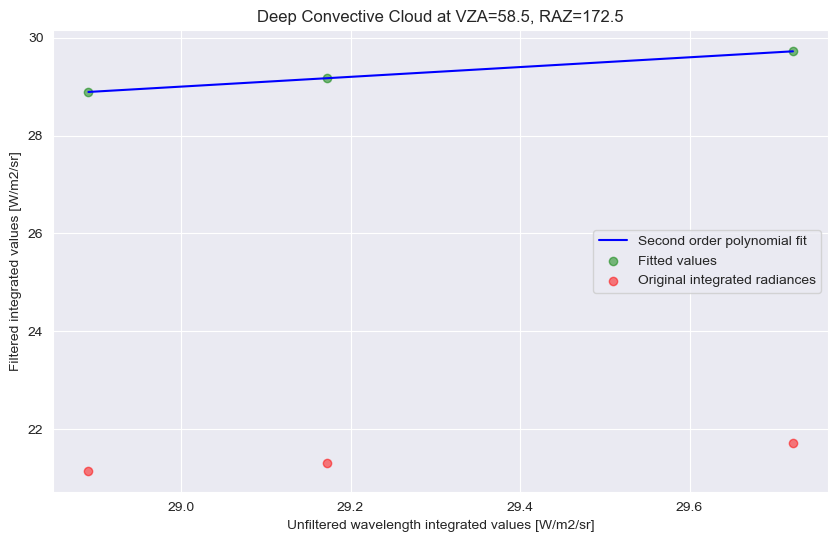

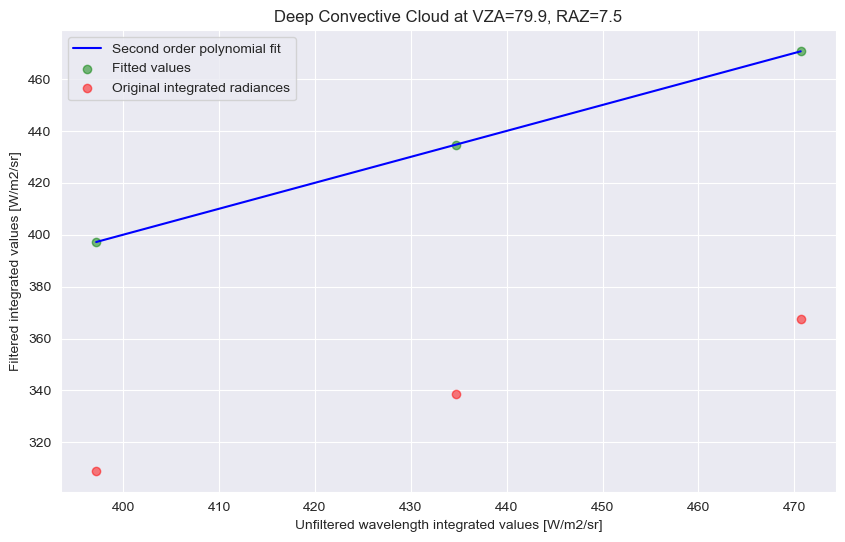

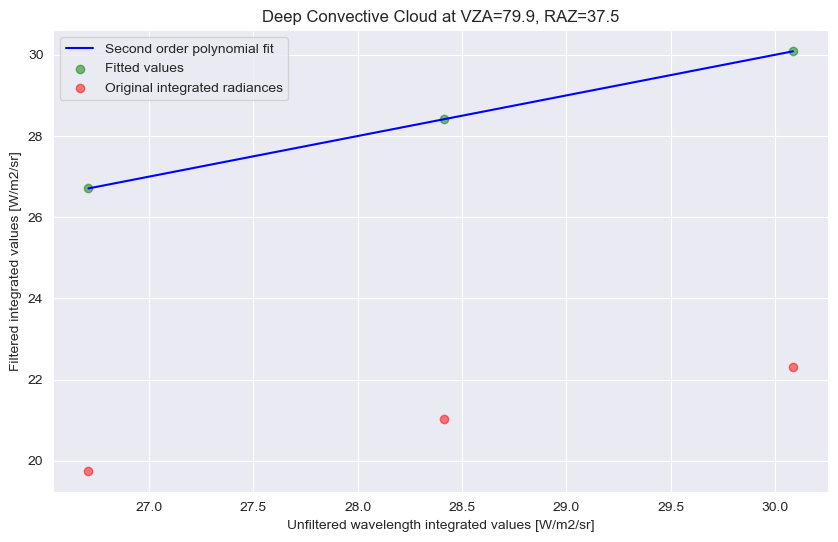

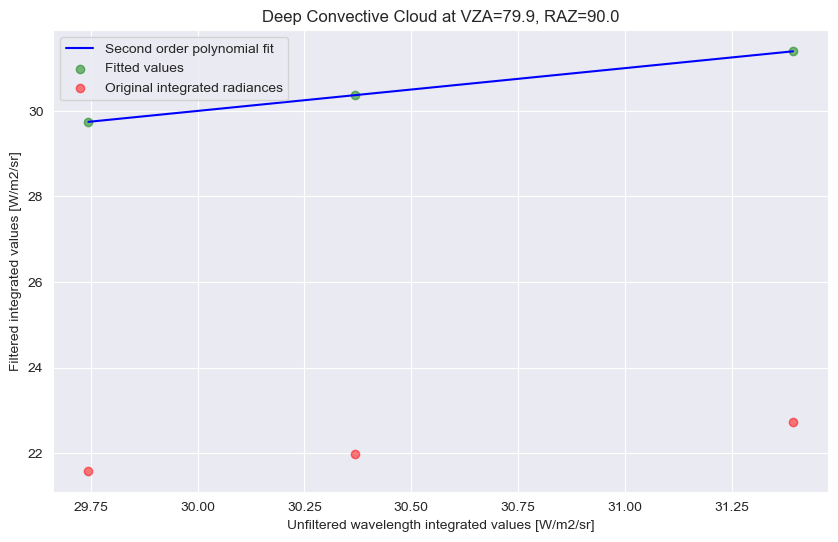

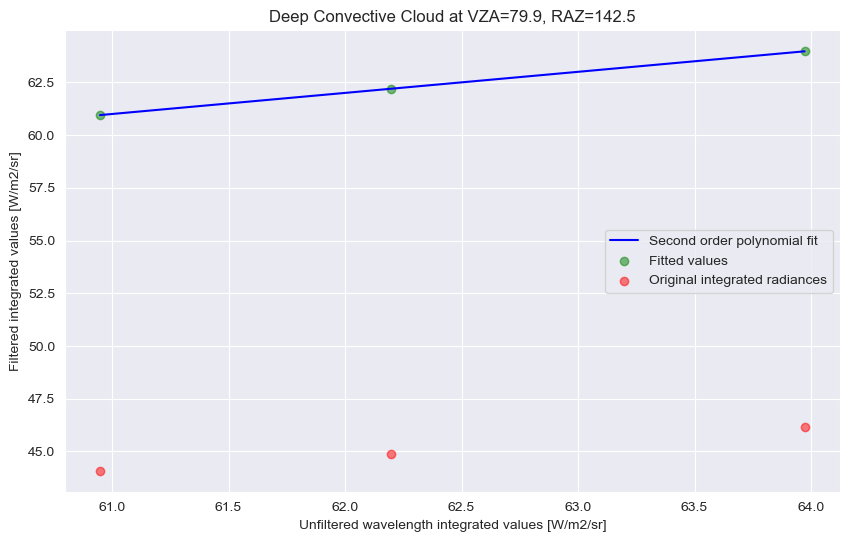

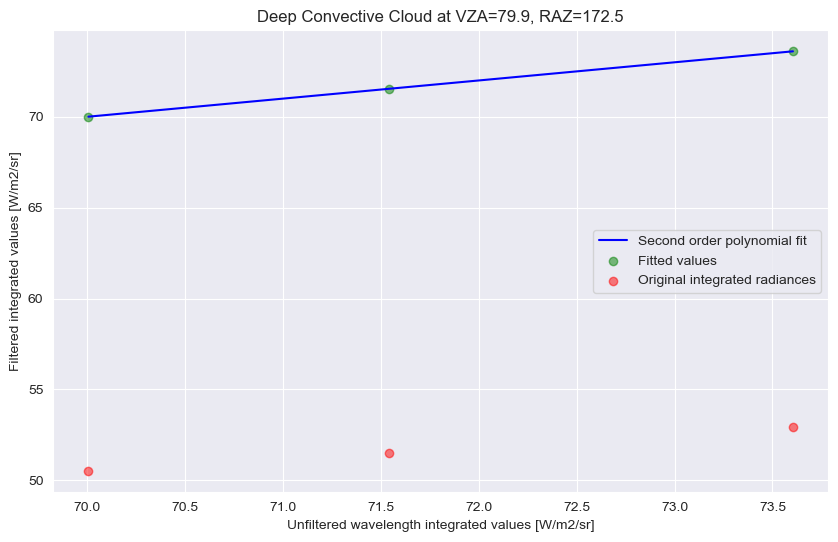

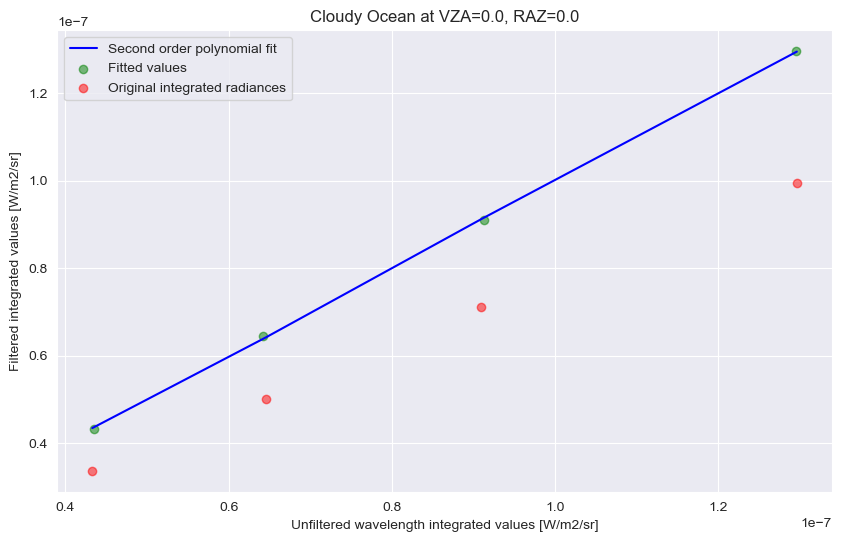

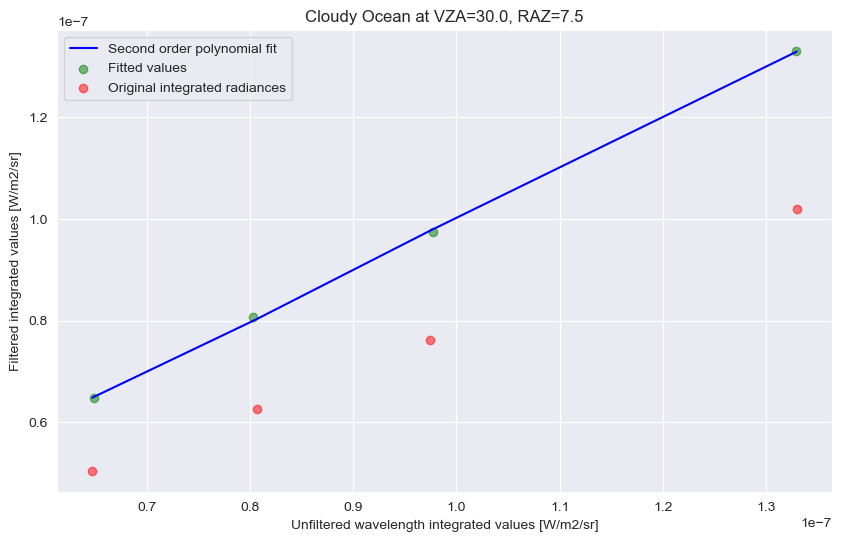

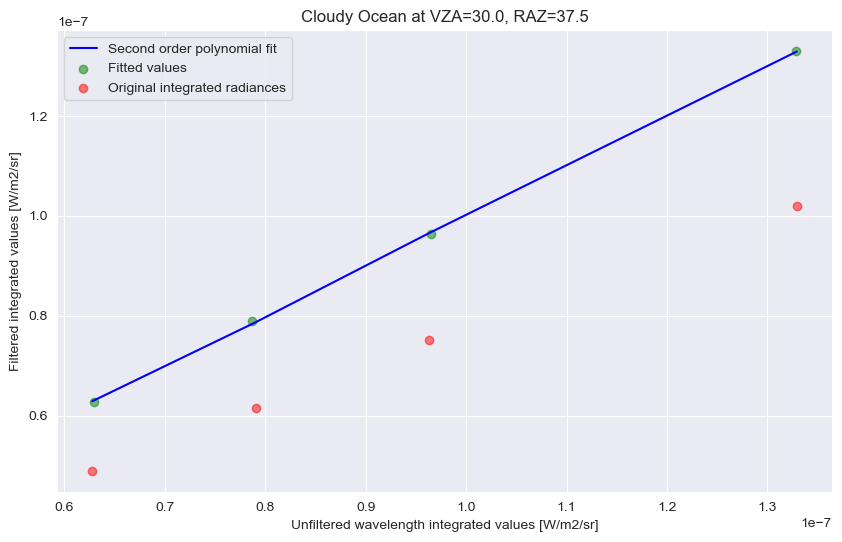

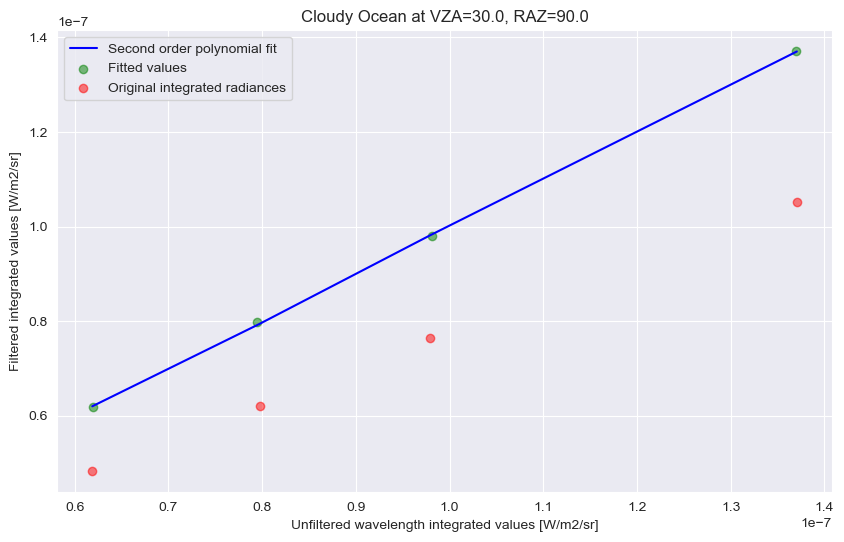

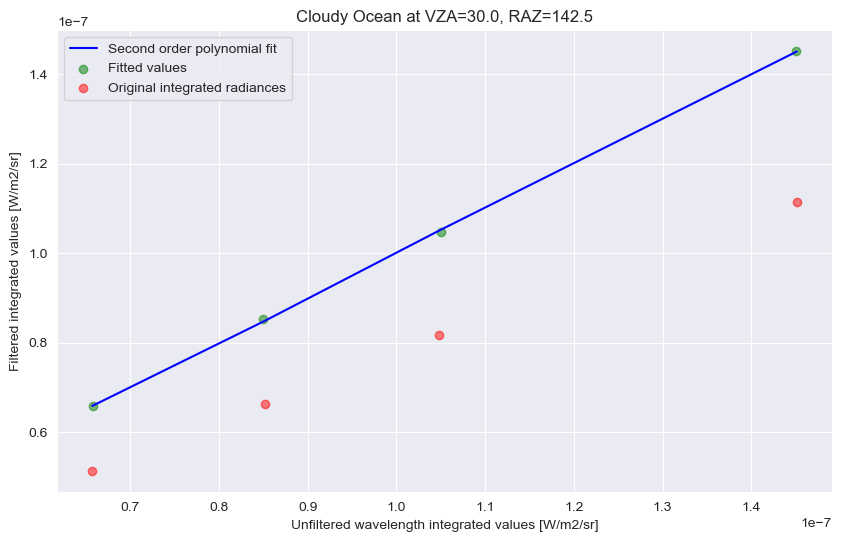

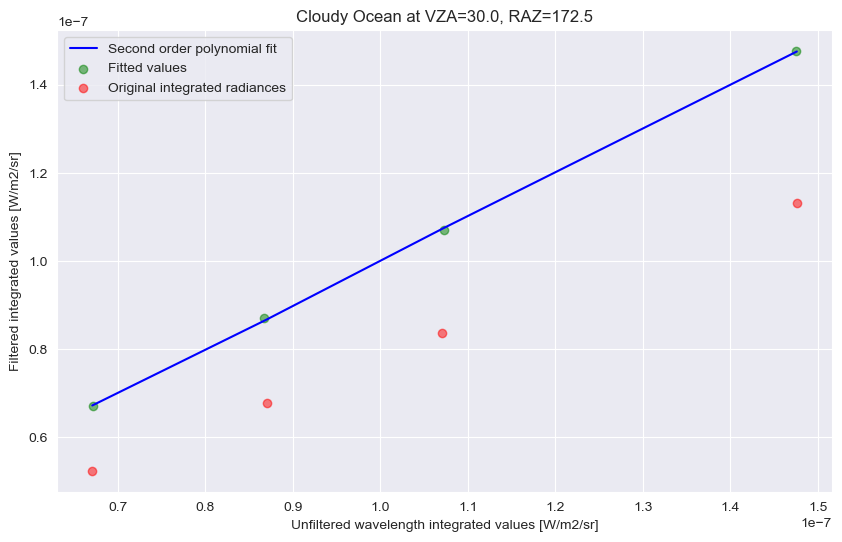

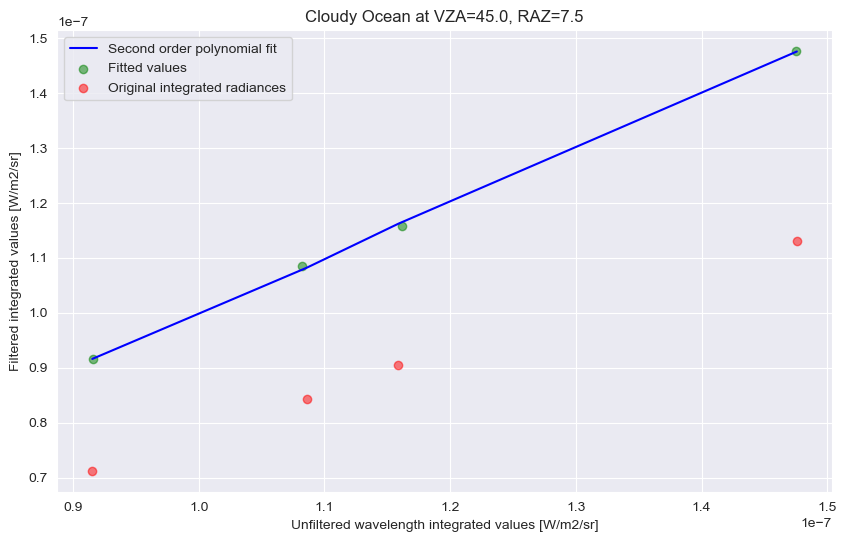

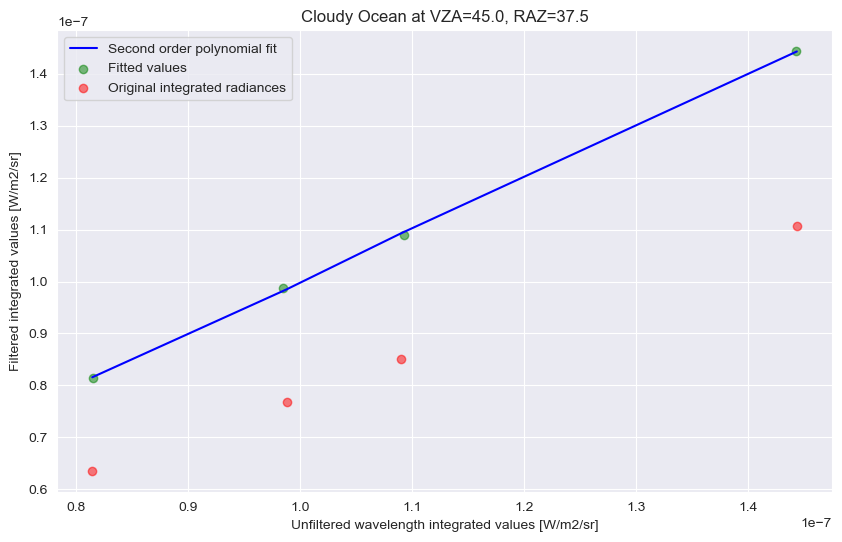

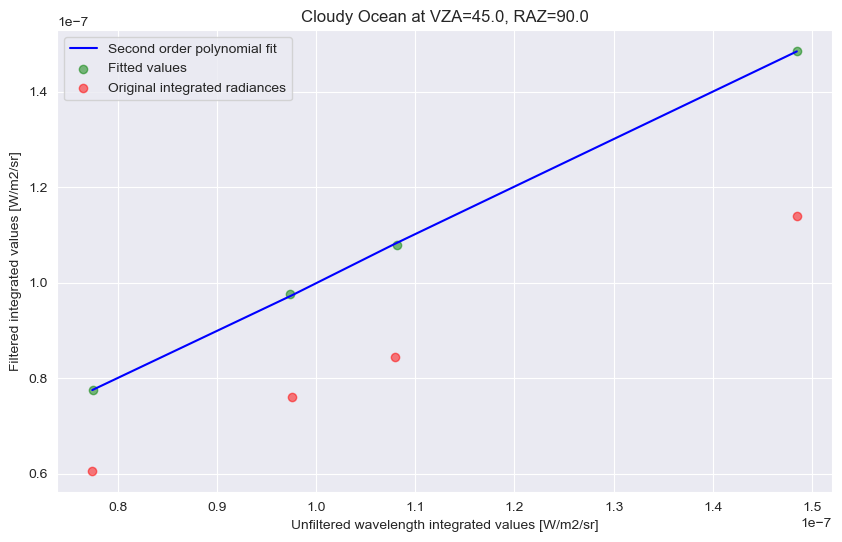

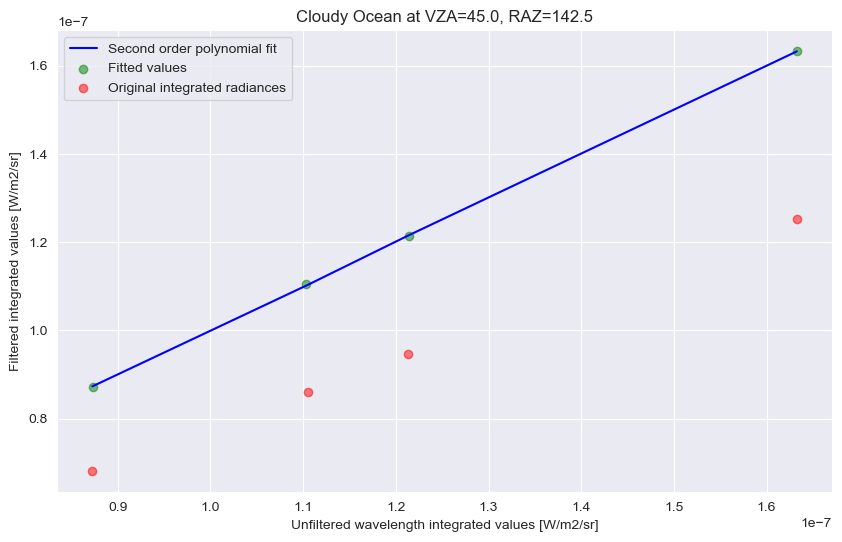

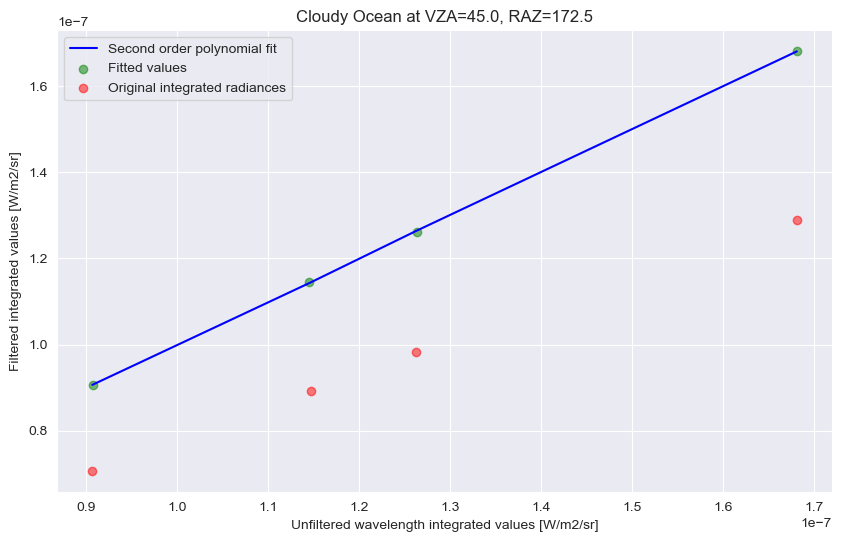

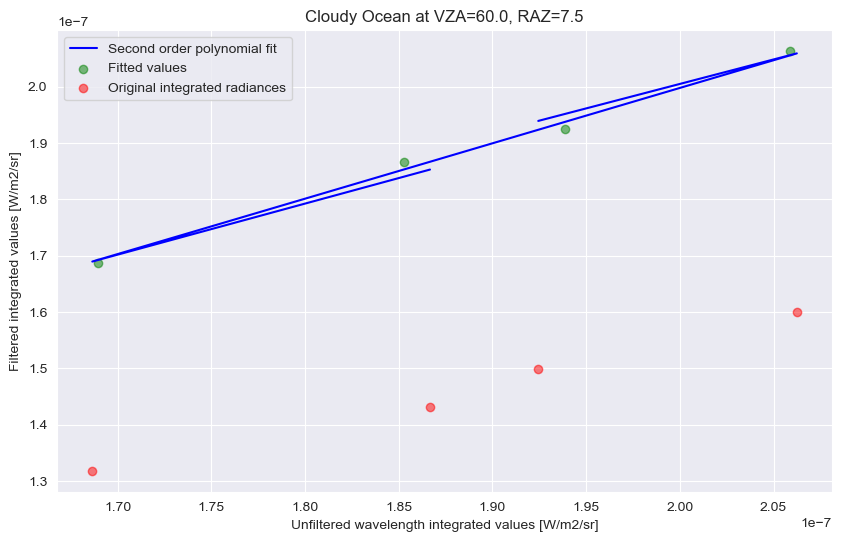

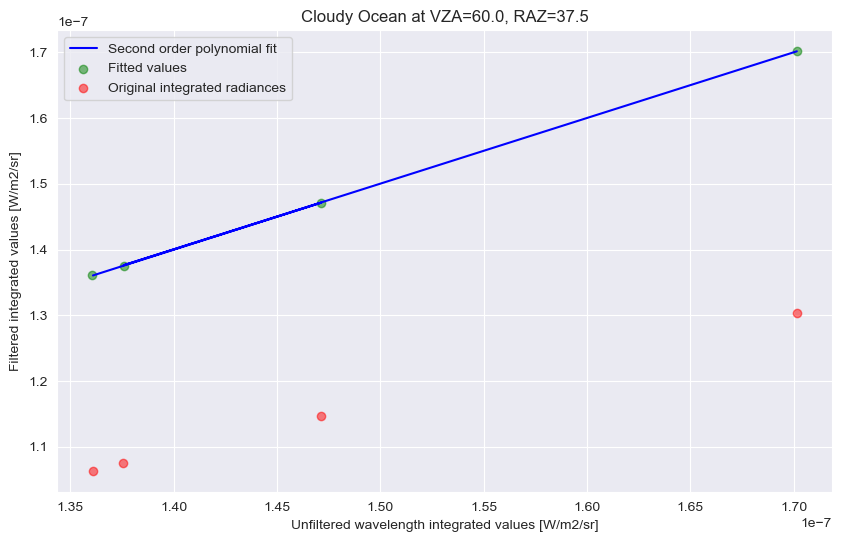

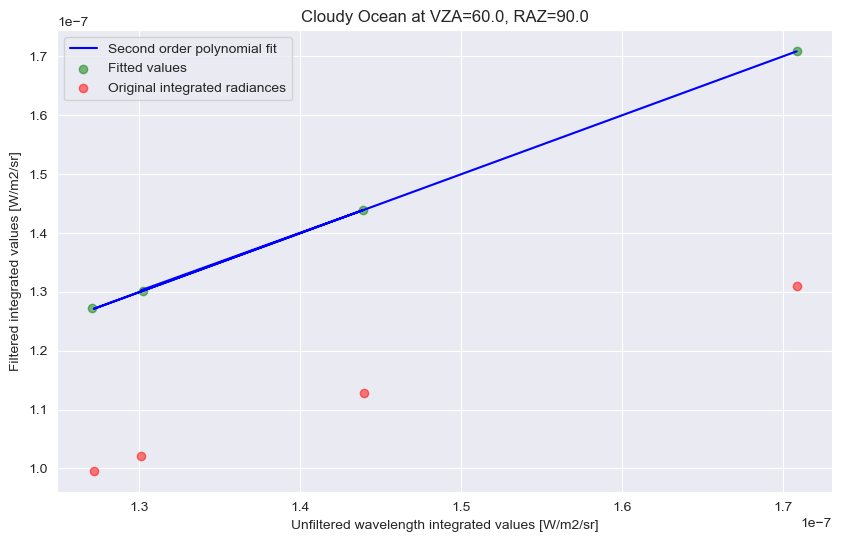

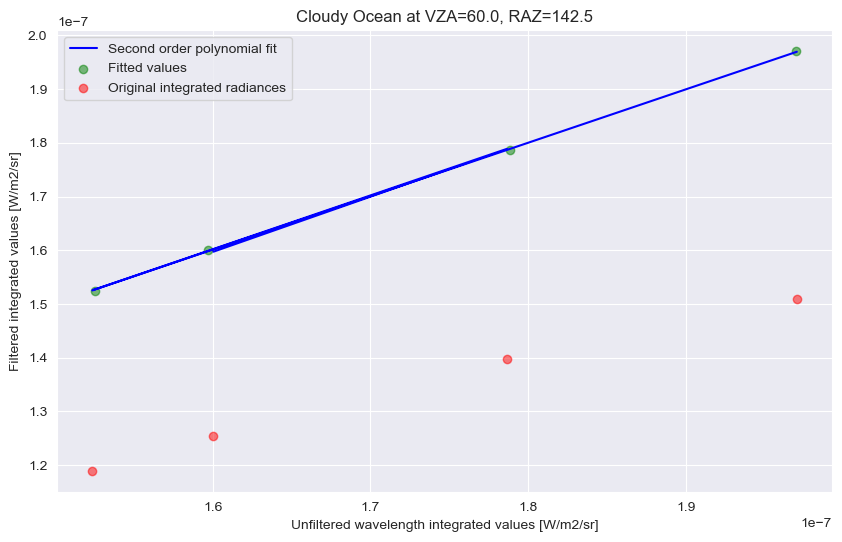

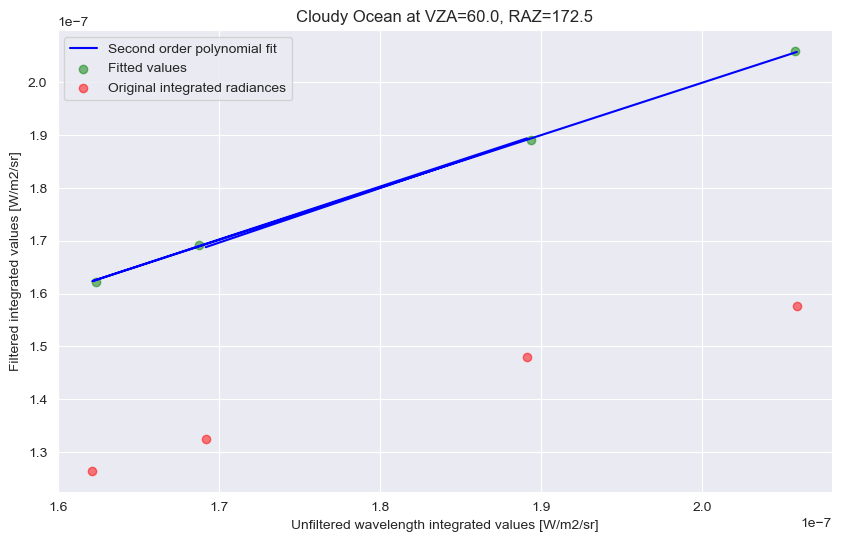

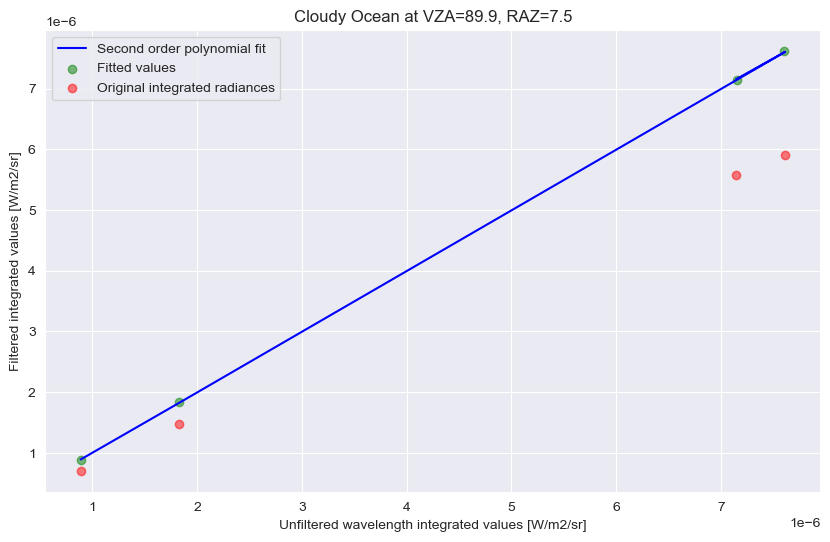

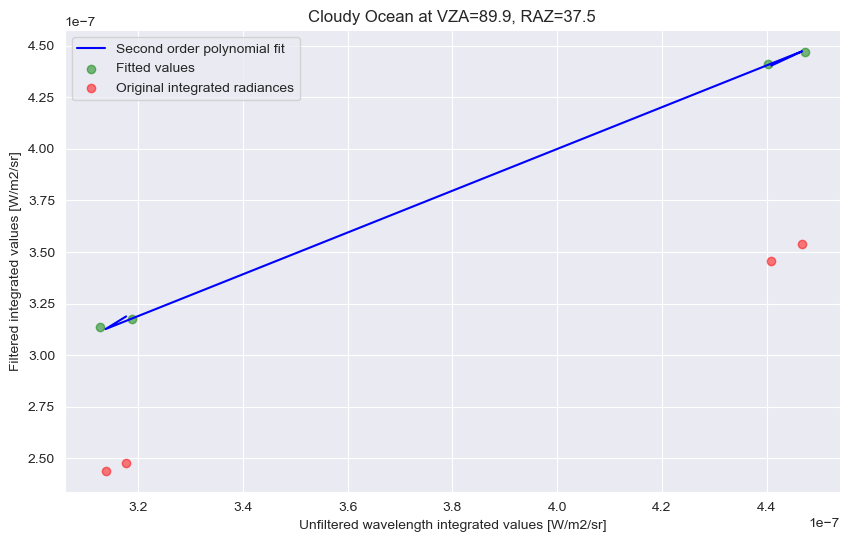

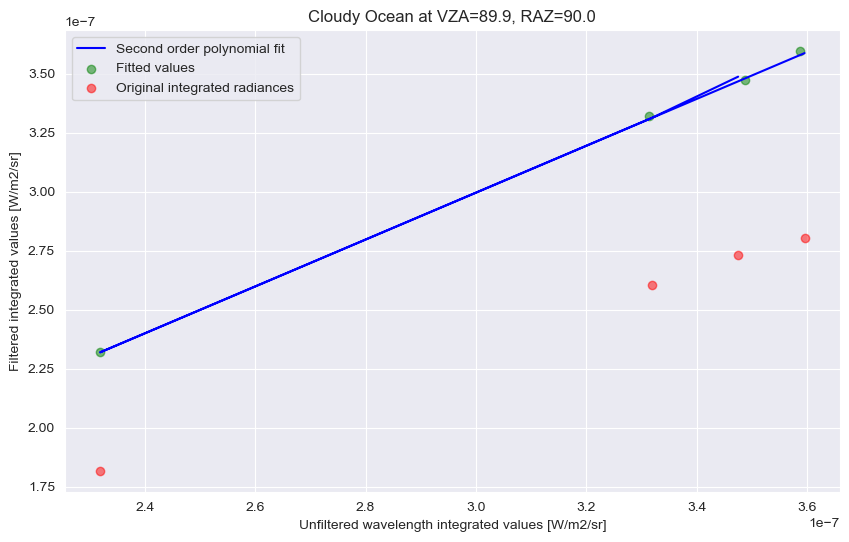

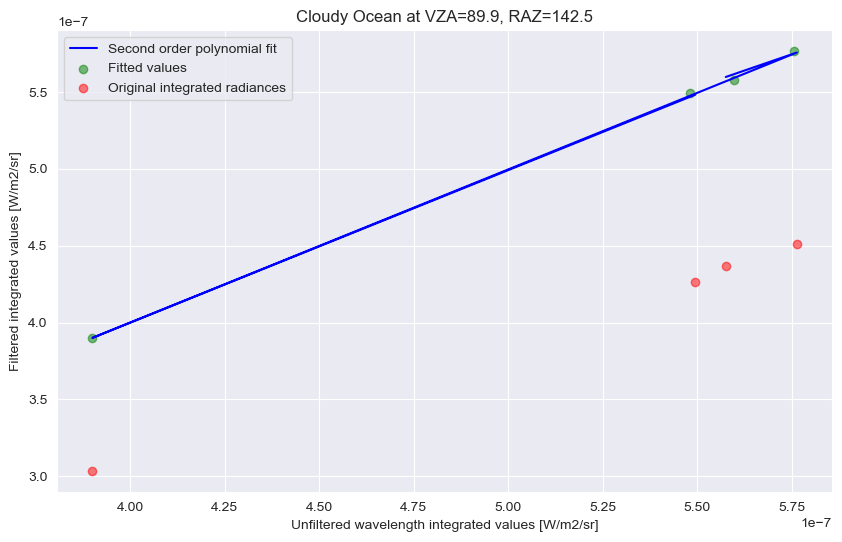

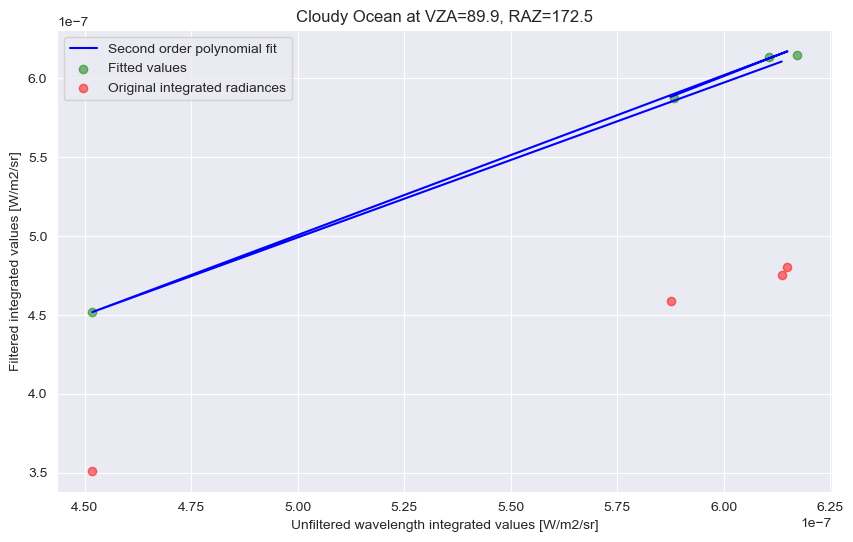

In [79]:
scenes = sza85['Scene'].unique()

for scene in scenes:
    scene_data = sza85[sza85['Scene'] == scene]

    # Group by VZA and RAZ combinations
    grouped = scene_data.groupby(['VZA', 'RAZ'])

    for (vza, raz), group in grouped:
        # Get shortwave data for this geometry
        sw_unfiltered = group['Shortwave Unfiltered Rads (Integrated)'].values
        sw_filtered = group['Shortwave Filtered Rads (Integrated)'].values

        # Calculate quadratic fit
        coefficients = np.polynomial.polynomial.polyfit(sw_filtered, sw_unfiltered, 2)
        sw_filter_fit = np.polynomial.polynomial.polyval(sw_filtered, coefficients)

        # Calculate relative error
        error = ((sw_filter_fit - sw_unfiltered) / sw_unfiltered) * 100

        # # Plot 1: Error plot
        # plt.figure(figsize=(10, 6))
        # plt.scatter(sw_unfiltered, error, color='pink', label='Geometries curve')
        # plt.xlabel("Shortwave unfiltered data [W/m2/sr]")
        # plt.ylabel("Percentage")
        # plt.title(f"Relative Error for {scene} at VZA={vza:.1f}, RAZ={raz:.1f}")
        # plt.ylim([-3, 3])
        # plt.legend()
        # plt.grid(True)
        # plt.show()

        # Plot 2: Filtered vs Unfiltered with fit
        plt.figure(figsize=(10, 6))
        plt.plot(sw_unfiltered, sw_filter_fit,
                label='Second order polynomial fit', color='blue')
        plt.scatter(sw_filter_fit, sw_unfiltered,
                   label='Fitted values', color='green', alpha=0.5)
        plt.scatter(sw_unfiltered, sw_filtered,
                   label='Original integrated radiances', color='red', alpha=0.5)

        plt.xlabel("Unfiltered wavelength integrated values [W/m2/sr]")
        plt.ylabel("Filtered integrated values [W/m2/sr]")

        # print(scene)
        # # Set plot limits based on scene type
        if 'OCEAN_CLOUD' in scene.upper():
            plt.xlim([0, 300])
            plt.ylim([0, 300])
        elif 'OCEAN_CLEAR' in scene.upper():
            plt.xlim([0, 200])
            plt.ylim([0, 200])
        elif 'SNOW' in scene.upper():
            plt.xlim([0, .0000005])
            plt.ylim([0, .0000005])

        plt.title(f"{scene} at VZA={vza:.1f}, RAZ={raz:.1f}")
        plt.legend()
        plt.grid(True)
        plt.show()